# CFM Volatility Forecasting Challenge — Notebook principal

**Auteur** : Adam Kerouredan  
**Référence méthodologique** : G. Paleologo, *The Elements of Quantitative Investing*, Wiley 2024

## Objectif

Prédire la volatilité réalisée 14h-16h d'actions US à partir de 54 barres intraday du matin (9h30-13h55).

L'enjeu n'est pas seulement de réduire une erreur moyenne : pour un desk ou une équipe risk, un modèle de volatilité doit être lisible, robuste sur un holdout temporel, et surtout défendable dans les régimes où la volatilité est élevée.

## Résultat final officiel

**LightGBM F (30 features structurées, n_estimators = 2000)** — MAPE holdout = **0.2398**, soit environ **-34.9%** par rapport à la baseline CFM sur le même holdout.

Le test `n_estimators = 3000` obtient une MAPE holdout de **0.2392**, mais il est traité comme un diagnostic exploratoire post-holdout et n'est pas retenu comme résultat officiel.

## Table des matières

| Phase | Description |
|-------|-------------|
| **0**    | Setup global, chemins, constantes et chargement des données |
| **I**    | Analyse exploratoire des données (EDA) |
| **II**   | Feature engineering |
| **III**  | Évaluation des features : IC, Spearman, Marchenko-Pastur |
| **IV**   | Neutralisation cross-sectionnelle |
| **V**    | Préparation à la modélisation |
| **VI**   | Modélisation : Ridge A, HAR-RV, LightGBM F |
| **VII**  | Validation industrielle du champion |
| **VIII** | Visualisations et observations |
| **IX**   | Tests de robustesse et pistes d'amélioration empirique |
| **X**    | Synthèse comparative et pistes futures |
| **XI**   | Génération du fichier de soumission |

---

# PHASE 0 — Setup global et chargement des données

## 0.1 Imports, chemins et constantes

Centralisation des imports, des chemins projet et des constantes partagées par le notebook.

## 0.2 Chargement des données

Trois fichiers fournis par CFM :
- `training_input.csv` : 636 313 lignes, 111 colonnes (3 meta + 54 vol + 54 retours)
- `Y_train.csv` : TARGET (volatilité réalisée 14h-16h)
- `testing_input.csv` : 635 397 lignes pour la soumission

**Note importante** : la variable `date` est anonymisée et randomisée par CFM. L'ordre chronologique réel inter-journalier est donc inaccessible. Cette contrainte interdit toute validation walk-forward et justifie l'usage d'une stratified K-Fold.

---

# PHASE I — Analyse exploratoire des données


In [2]:
# ============================================================
# 0. SETUP — Imports, chemins et constantes globales
# ============================================================
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kendalltau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

from src.data_loader import DataLoader
from src.eda_analyzer import EDAAnalyzer
from src.feature_engineer import FeatureEngineer, FeatureTransformer
from src.neutralizer import Neutralizer
from src.splitter import Splitter
from src.evaluator import Evaluator
from src.validator import Validator
from src.model import (
    LightGBMModel,
    RidgeModel,
    make_lightgbm_train_fn,
    make_ridge_train_fn,
    predict_fn,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "TARGET"
ID_COL = "ID"

loader = DataLoader(data_dir=DATA_DIR)
x_train, y_train, x_test = loader.load_all()

target_series = y_train[TARGET_COL]
target_values = target_series.to_numpy()
target_log = np.log(target_values)

meta_full = x_train[["date", "product_id"]].reset_index(drop=True)
meta_test_full = x_test[["date", "product_id"]].reset_index(drop=True)

volatility_columns = x_train.filter(regex=r"^volatility").columns.tolist()
return_columns = x_train.filter(regex=r"^return").columns.tolist()
raw_bar_columns = volatility_columns + return_columns

volatility_data_imputed = (
    x_train.loc[:, volatility_columns]
    .interpolate(method="linear", axis=1)
    .ffill(axis=1)
    .bfill(axis=1)
    .to_numpy()
)

print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")


[WARNING] x_train contient 839634 valeurs manquantes.
[WARNING] x_test contient 875392 valeurs manquantes.
x_train : (636313, 111)
y_train : (636313, 2)
x_test  : (635397, 111)


## 1.2 EDA générale

Analyse exhaustive : dimensions, valeurs manquantes, distribution de la TARGET, persistance de volatilité, profil intraday.

DESCRIPTION DU DATASET
  Lignes totales        :    636,313
  Colonnes totales      :        111
  Stocks uniques        :        318
  Jours uniques         :      2,117
  Colonnes volatilité   :         54
  Colonnes return dir.  :         54

VALEURS MANQUANTES
  Lignes avec au moins 1 NaN : 99,701 (15.7%)
  NaN moyen par ligne        : 0.66
  Max NaN sur une ligne      : 53


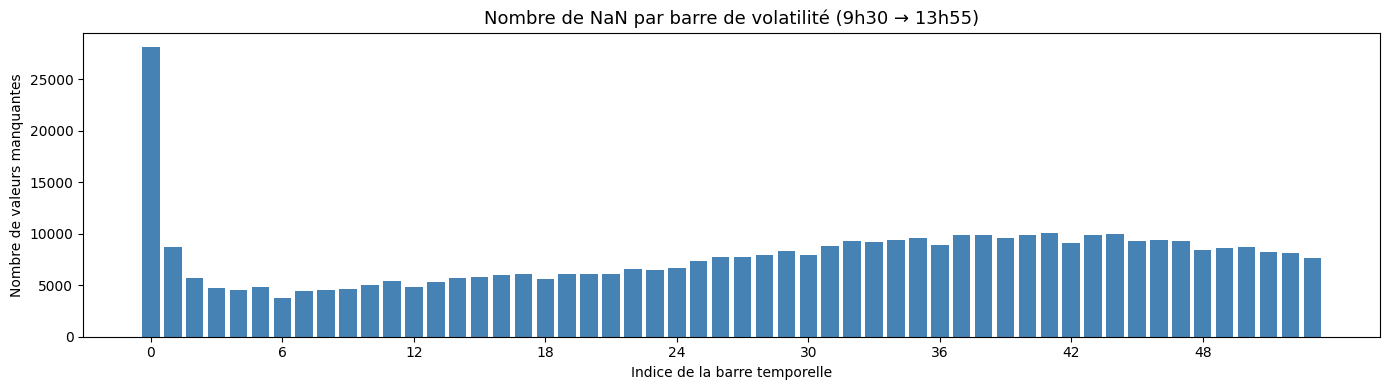


DISTRIBUTION DE LA TARGET (vol 14h-16h)
count    636313.000000
mean          0.183569
std           0.155562
min           0.000132
25%           0.098403
50%           0.141679
75%           0.214632
max           7.581517

  Skewness  : 5.014
  Kurtosis  : 59.902


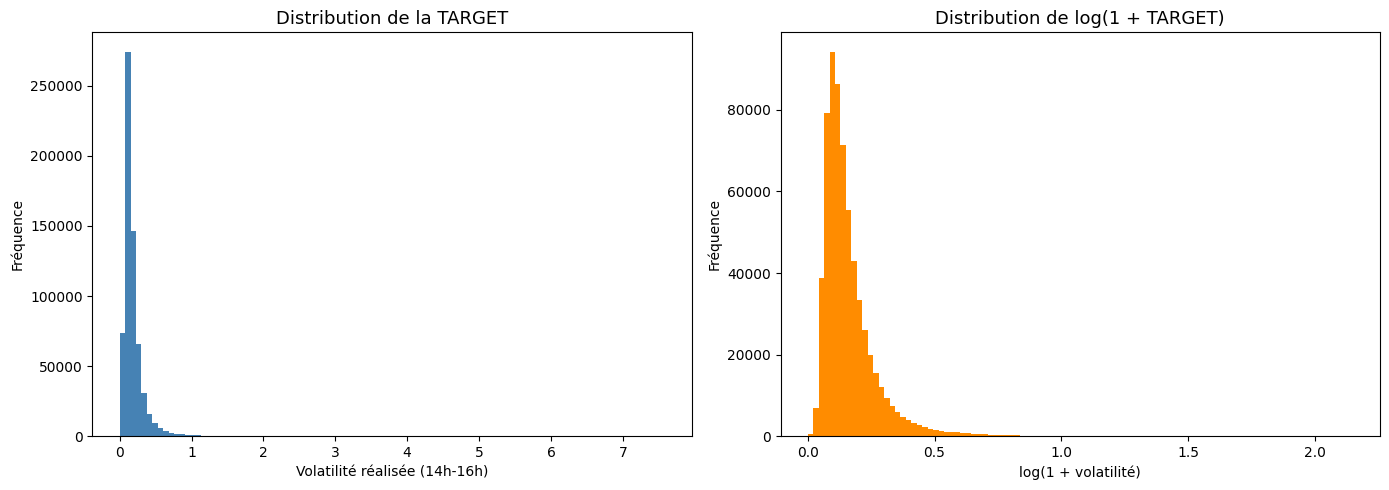


PERSISTANCE DE LA VOLATILITÉ
  Corrélation vol matin / TARGET : 0.8573


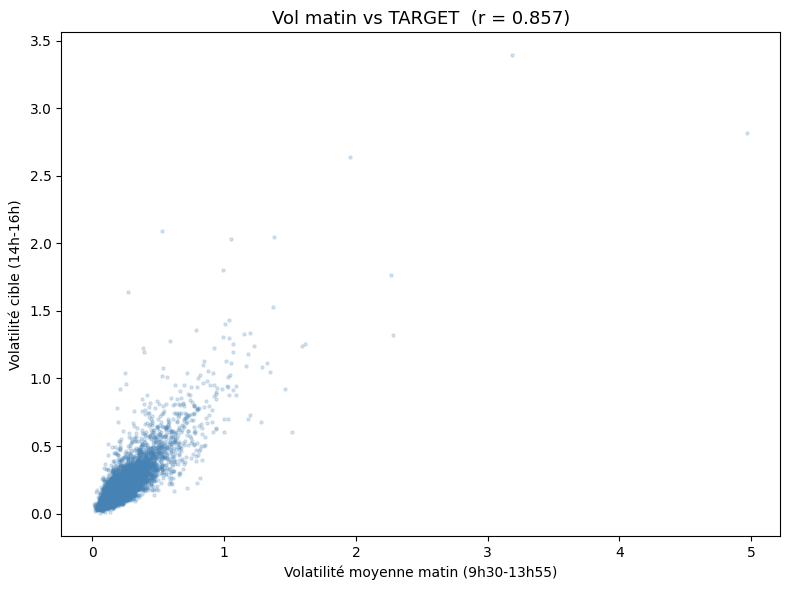

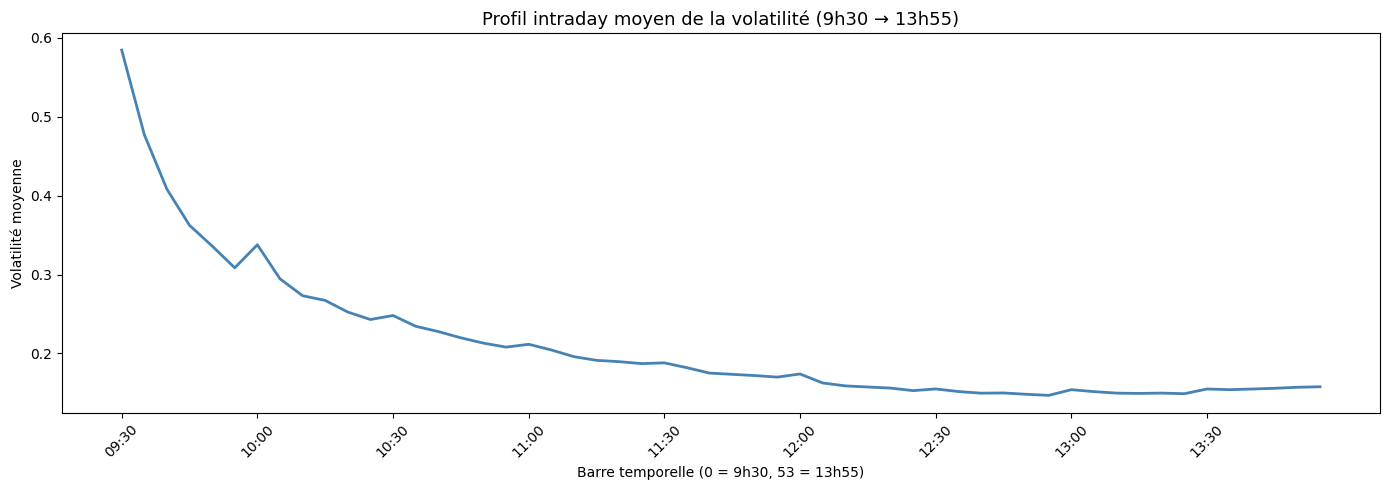

In [3]:
eda = EDAAnalyzer(x_train, y_train, output_dir=OUTPUT_DIR)
eda.run()

## 1.3 Structure des NaN et profil intraday

**Observations clés** :
- 15,7% des lignes contiennent au moins un NaN
- Concentration à 09h30 (28 091 NaN) — microstructure d'auction d'ouverture
- Profil intraday décroissant en "L" (vol pic à 09h30 puis stabilisation) — pas un U classique car données coupées à 13h55

In [4]:

# NaN par barre temporelle
missing_per_bar_table = pd.DataFrame({
    "missing_values": x_train[volatility_columns].isna().sum(),
    "mean_volatility": x_train[volatility_columns].mean(),
})

print("Aperçu des NaN et de la volatilité moyenne par barre intraday")
display(pd.concat([
    missing_per_bar_table.head(),
    missing_per_bar_table.tail(),
]))

intraday_profile_table = (
    missing_per_bar_table
    .iloc[::6]
    .rename_axis("bar")
    .reset_index()
)

print("Profil intraday — une barre sur six")
display(intraday_profile_table)


Aperçu des NaN et de la volatilité moyenne par barre intraday


,missing_values,mean_volatility
volatility 09:30:00,28091,0.584382
volatility 09:35:00,8755,0.477272
volatility 09:40:00,5657,0.408130
volatility 09:45:00,4756,0.362365
volatility 09:50:00,4536,0.336104
volatility 13:35:00,8606,0.154111
volatility 13:40:00,8746,0.154923
volatility 13:45:00,8230,0.155864
volatility 13:50:00,8166,0.157149
volatility 13:55:00,7671,0.157785


Profil intraday — une barre sur six


,bar,missing_values,mean_volatility
0,volatility 09:30:00,28091,0.584382
1,volatility 10:00:00,3805,0.337733
2,volatility 10:30:00,4824,0.248104
3,volatility 11:00:00,5605,0.211613
4,volatility 11:30:00,6657,0.188078
5,volatility 12:00:00,7975,0.173996
6,volatility 12:30:00,8889,0.155027
7,volatility 13:00:00,9076,0.154092
8,volatility 13:30:00,8418,0.154943


## 1.4 Distribution de la TARGET — détection des outliers

**Statistiques** :
- Médiane : 0.142
- Skewness : 5.01 (très asymétrique)
- Kurtosis : 59.9 (queues extrêmes)
- Min : 0.000132 (problématique pour MAPE)
- Max : 7.58

**Implication critique** : la TARGET minimale à 0.000132 fait exploser la métrique MAPE. Une erreur absolue de 0.02 sur une vraie vol de 0.05 donne un MAPE de 40%. Cette propriété guidera plusieurs décisions méthodologiques.

In [5]:

target_extreme_thresholds = pd.DataFrame({
    "statistique": [
        "99.5e percentile",
        "99.9e percentile",
        "maximum",
        "valeurs > 99.5p",
        "valeurs > 99.9p",
    ],
    "valeur": [
        np.percentile(target_series, 99.5),
        np.percentile(target_series, 99.9),
        target_series.max(),
        (target_series > np.percentile(target_series, 99.5)).sum(),
        (target_series > np.percentile(target_series, 99.9)).sum(),
    ],
})

display(target_extreme_thresholds)


,statistique,valeur
0,99.5e percentile,1.022512
1,99.9e percentile,1.593053
2,maximum,7.581517
3,valeurs > 99.5p,3182.000000
4,valeurs > 99.9p,637.000000


---

# PHASE II — Feature engineering

## 2.1 Construction des 10 features

**Imputation des NaN** : interpolation linéaire intraday + forward-fill + backward-fill, appliquée ligne par ligne sur l'axe temporel des 54 barres. Aucun leakage car aucune information cross-ligne n'est utilisée.

**Features construites** (10 retenues sur 16 initiales) :

| Famille | Features | Hypothèse économique |
|---------|----------|---------------------|
| Niveau global | `vol_mean` | Persistance de volatilité |
| Asymétrie | `vol_mean_minus_median` | Présence de pics isolés |
| Récence | `vol_mean_recent`, `vol_last_bar` | Proximité de la fenêtre cible |
| Tendance | `vol_linear_slope` | Direction du profil intraday |
| Dispersion | `vol_std`, `vol_min` | Stabilité du régime |
| Accélération | `vol_recent_over_mean` | Dynamique récente vs globale |
| Directionnel | `return_n_positive`, `return_n_negative` | Biais directionnel intraday |

**Features supprimées et pourquoi** :
- `vol_median` (r = 0.969 avec `vol_mean`)
- `vol_trend` (r = 0.918 avec `vol_linear_slope`)
- `vol_max` (r = 0.956 avec `vol_std`)
- `vol_range` (r = 0.999 avec `vol_max`)
- `return_direction_bias` (IC = -0.048, pas de signal)
- `return_last_bar` (IC = +0.002, pas de signal)

In [6]:

engineer = FeatureEngineer(x_train, x_test)
features_train, features_test = engineer.build()

feature_engineering_summary = pd.DataFrame({
    "objet": ["features_train", "features_test"],
    "lignes": [features_train.shape[0], features_test.shape[0]],
    "colonnes": [features_train.shape[1], features_test.shape[1]],
})

feature_list_table = pd.DataFrame({
    "feature": features_train.columns.drop(ID_COL),
})

print("Résumé feature engineering")
display(feature_engineering_summary)

print("Features retenues")
display(feature_list_table)


Résumé feature engineering


,objet,lignes,colonnes
0,features_train,636313,11
1,features_test,635397,11


Features retenues


,feature
0,vol_mean
1,vol_mean_minus_median
2,vol_mean_recent
3,vol_last_bar
4,vol_linear_slope
5,vol_std
6,vol_min
7,vol_recent_over_mean
8,return_n_positive
9,return_n_negative


## 2.2 Variables partagées du notebook


In [7]:
# Variables centrales issues du feature engineering
feature_cols = features_train.columns.drop(ID_COL).tolist()

shared_variables_summary = pd.DataFrame({
    "variable": [
        "feature_cols",
        "volatility_columns",
        "return_columns",
        "raw_bar_columns",
    ],
    "nombre": [
        len(feature_cols),
        len(volatility_columns),
        len(return_columns),
        len(raw_bar_columns),
    ],
})

display(shared_variables_summary)


,variable,nombre
0,feature_cols,10
1,volatility_columns,54
2,return_columns,54
3,raw_bar_columns,108


## 2.3 Vérifications post-engineering

In [8]:

# Shapes, NaN résiduels, alignement ID
aligned_ids = (features_train[ID_COL].to_numpy() == y_train[ID_COL].to_numpy()).all()

quality_checks_table = pd.DataFrame({
    "contrôle": [
        "NaN résiduels features_train",
        "NaN résiduels features_test",
        "Alignement ID train/target",
    ],
    "valeur": [
        features_train.isna().sum().sum(),
        features_test.isna().sum().sum(),
        aligned_ids,
    ],
})

print("Contrôles qualité")
display(quality_checks_table)

print("Statistiques descriptives des features")
display(features_train[feature_cols].describe().round(4))


Contrôles qualité


,contrôle,valeur
0,NaN résiduels features_train,0
1,NaN résiduels features_test,0
2,Alignement ID train/target,True


Statistiques descriptives des features


,vol_mean,vol_mean_minus_median,vol_mean_recent,vol_last_bar,vol_linear_slope,vol_std,vol_min,vol_recent_over_mean,return_n_positive,return_n_negative
count,636313.0000,636313.0000,636313.0000,636313.0000,636313.0000,636313.0000,636313.0000,636313.0000,636313.0000,636313.0000
mean,0.2108,0.0508,0.1548,0.1568,-0.0045,0.1827,0.0206,0.7188,22.9775,23.0684
std,0.1499,0.0442,0.1497,0.1990,0.0042,0.1337,0.0318,0.3113,5.0431,5.1507
min,0.0001,-0.7676,0.0000,0.0000,-0.2451,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.1243,0.0262,0.0757,0.0509,-0.0057,0.1072,0.0000,0.5204,20.0000,20.0000
50%,0.1712,0.0403,0.1174,0.1033,-0.0037,0.1484,0.0115,0.6805,23.0000,24.0000
75%,0.2480,0.0621,0.1854,0.1943,-0.0023,0.2150,0.0288,0.8699,26.0000,27.0000
max,5.9799,2.7463,9.3545,12.1173,0.2011,6.3999,2.2411,9.0000,43.0000,43.0000


---

# PHASE III — Évaluation des features

## 3.1 Information Coefficient (Pearson, Kendall τ, cross-sectionnel)

**Référence** : Paleologo (2024), Chap. 8 — Information Coefficient.

Trois métriques calculées :
- **IC Pearson** (linéaire)
- **IC Kendall τ** (rangs, robuste outliers)
- **IC cross-sectionnel Spearman par date** avec t-stat sur 2 117 jours

**Résultats clés** : tous les t-stats > 35, signaux statistiquement très robustes.

In [9]:

print("=" * 60)
print("IC PEARSON vs log(TARGET)")
print("=" * 60)

target_log_series = pd.Series(target_log, index=features_train.index)

pearson_table = (
    features_train[feature_cols]
    .corrwith(target_log_series)
    .rename("pearson")
    .reset_index()
    .rename(columns={"index": "feature"})
    .assign(abs_pearson=lambda data: data["pearson"].abs())
    .sort_values("abs_pearson", ascending=False)
)

ic_pearson = pearson_table.set_index("feature")["pearson"].to_dict()

print(
    pearson_table[["feature", "pearson"]]
    .to_string(
        index=False,
        header=False,
        formatters={"pearson": lambda value: f"{value:+.4f}"},
    )
)

print("\n" + "=" * 60)
print("IC KENDALL TAU vs log(TARGET)")
print("=" * 60)

def compute_kendall_statistics(feature_series):
    kendall_tau, p_value = kendalltau(feature_series.to_numpy(), target_log)
    return pd.Series({"kendall_tau": kendall_tau, "p_value": p_value})

kendall_table = (
    features_train[feature_cols]
    .apply(compute_kendall_statistics)
    .T
    .rename_axis("feature")
    .reset_index()
    .assign(abs_kendall_tau=lambda data: data["kendall_tau"].abs())
    .sort_values("abs_kendall_tau", ascending=False)
)

ic_kendall = (
    kendall_table
    .set_index("feature")[["kendall_tau", "p_value"]]
    .apply(tuple, axis=1)
    .to_dict()
)

print(f"  {'Feature':<30} {'Kendall tau':>12} {'p-value':>12}")
print(
    kendall_table[["feature", "kendall_tau", "p_value"]]
    .to_string(
        index=False,
        header=False,
        formatters={
            "feature": lambda value: f"  {value:<30}",
            "kendall_tau": lambda value: f"{value:>+12.4f}",
            "p_value": lambda value: f"{value:>12.2e}",
        },
    )
)


IC PEARSON vs log(TARGET)
             vol_mean +0.7682
      vol_mean_recent +0.6777
              vol_std +0.6533
              vol_min +0.5621
         vol_last_bar +0.5342
vol_mean_minus_median +0.5191
     vol_linear_slope -0.4211
    return_n_negative +0.2116
 vol_recent_over_mean +0.1918
    return_n_positive +0.1490

IC KENDALL TAU vs log(TARGET)
  Feature                         Kendall tau      p-value
  vol_mean                            +0.6287     0.00e+00
  vol_mean_recent                     +0.5518     0.00e+00
  vol_std                             +0.5170     0.00e+00
  vol_last_bar                        +0.3678     0.00e+00
  vol_mean_minus_median               +0.3571     0.00e+00
  vol_min                             +0.3372     0.00e+00
  vol_linear_slope                    -0.2707     0.00e+00
  return_n_negative                   +0.1359     0.00e+00
  vol_recent_over_mean                +0.1354     0.00e+00
  return_n_positive                   +0.0885     0.0

## 3.2 Matrice Spearman + IC cross-sectionnel

Audit de la multicolinéarité résiduelle entre features pour s'assurer qu'aucune paire critique ne perturbe les modèles linéaires.

In [10]:

print("=" * 60)
print("MATRICE SPEARMAN ENTRE FEATURES")
print("=" * 60)

spearman_matrix = features_train[feature_cols].corr(method="spearman")
print(spearman_matrix.round(3).to_string())

print("\n" + "=" * 60)
print("IC CROSS-SECTIONNEL MOYEN (Spearman par date)")
print("=" * 60)

features_with_date = (
    features_train[feature_cols]
    .assign(
        date=x_train["date"].to_numpy(),
        target_log=target_log,
    )
)

valid_dates = (
    features_with_date
    .groupby("date")
    .size()
    .loc[lambda observations_by_date: observations_by_date.ge(10)]
    .index
)

cross_section_ic_by_date = (
    features_with_date
    .loc[features_with_date["date"].isin(valid_dates)]
    .groupby("date")[feature_cols + ["target_log"]]
    .corr(method="spearman")
    .loc[(slice(None), feature_cols), "target_log"]
    .rename("ic")
    .reset_index()
    .rename(columns={"level_1": "feature"})
    .pivot(index="date", columns="feature", values="ic")
)

cross_section_summary = pd.DataFrame({
    "IC moyen": cross_section_ic_by_date.mean(),
    "IC std": cross_section_ic_by_date.std(),
    "n dates": cross_section_ic_by_date.count(),
}).loc[feature_cols]

cross_section_summary["t-stat"] = (
    cross_section_summary["IC moyen"]
    .div(cross_section_summary["IC std"].div(np.sqrt(cross_section_summary["n dates"])))
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

print(f"  {'Feature':<30} {'IC moyen':>10} {'IC std':>10} {'t-stat':>10}")
print(
    cross_section_summary
    .reset_index(names="feature")[["feature", "IC moyen", "IC std", "t-stat"]]
    .to_string(
        index=False,
        header=False,
        formatters={
            "feature": lambda value: f"  {value:<30}",
            "IC moyen": lambda value: f"{value:>+10.4f}",
            "IC std": lambda value: f"{value:>10.4f}",
            "t-stat": lambda value: f"{value:>+10.2f}",
        },
    )
)


MATRICE SPEARMAN ENTRE FEATURES
                       vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope  vol_std  vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
vol_mean                  1.000                  0.644            0.792         0.543            -0.609    0.879    0.537                 0.078              0.226              0.267
vol_mean_minus_median     0.644                  1.000            0.425         0.278            -0.626    0.822    0.219                -0.109              0.036              0.042
vol_mean_recent           0.792                  0.425            1.000         0.673            -0.240    0.631    0.490                 0.625              0.196              0.256
vol_last_bar              0.543                  0.278            0.673         1.000            -0.175    0.418    0.383                 0.421              0.164              0.215
vol_linear_slope         -0.609                 -0.626    

## 3.3 Diagnostic Marchenko-Pastur — composantes réelles

**Théorie** : la loi de Marchenko-Pastur (1967) donne la distribution théorique des valeurs propres d'une matrice de covariance de bruit pur avec ratio $\gamma = p/n$.

**Application** : 10 features, 636 313 observations → $\gamma \approx 1.6 \times 10^{-5}$, bord supérieur $\lambda_+ \approx 1.0080$.

**Résultat numérique** : 3 composantes ressortent au-dessus du bruit de Marchenko-Pastur :

- **PC1 = 4.7474** : niveau global de volatilité intraday.
- **PC2 = 1.6811** : forme temporelle / dynamique récente de la volatilité.
- **PC3 = 1.1637** : information additionnelle plus faible, probablement liée à l'asymétrie directionnelle et aux écarts de profil.

**Lecture économique** : le signal n'est pas réparti uniformément sur les 10 features. Une grande partie de l'information vient d'un facteur de niveau de volatilité, puis de quelques dimensions secondaires. Cela valide l'idée de tester un modèle PCA/Ridge comme benchmark compact.

**Décision de modélisation** : la PCA est utile comme diagnostic de structure, mais elle n'est pas nécessairement optimale pour la prédiction finale : elle compresse l'information, perd l'interprétabilité feature par feature, et peut effacer des non-linéarités utiles pour LightGBM.

In [11]:

# Ratio dimensions / observations
p     = len(feature_cols)
n     = len(features_train)
gamma = p / n

# Bornes Marchenko-Pastur (variance unitaire après StandardScaler)
sigma2       = 1.0
lambda_plus  = sigma2 * (1 + np.sqrt(gamma)) ** 2
lambda_minus = sigma2 * (1 - np.sqrt(gamma)) ** 2

print(f"p (features)     : {p}")
print(f"n (observations) : {n:,}")
print(f"gamma            : {gamma:.6f}")
print(f"lambda_+         : {lambda_plus:.6f}")
print(f"lambda_-         : {lambda_minus:.6f}")

# Calcul des valeurs propres empiriques
X_scaled    = StandardScaler().fit_transform(features_train[feature_cols])
cov_matrix  = np.cov(X_scaled.T)
eigenvalues = np.linalg.eigvalsh(cov_matrix)[::-1]

mp_components = pd.DataFrame({
    "component_number": np.arange(1, len(eigenvalues) + 1),
    "eigenvalue": eigenvalues,
})
mp_components["component"] = "PC" + mp_components["component_number"].astype(str).str.rjust(2)
mp_components["status"] = np.where(
    mp_components["eigenvalue"].gt(lambda_plus),
    "SIGNAL",
    "BRUIT",
)

n_signal = int(mp_components["status"].eq("SIGNAL").sum())

print("\nValeurs propres empiriques vs bord MP :")
print(
    mp_components[["component", "eigenvalue", "status"]]
    .to_string(
        index=False,
        header=False,
        formatters={
            "component": lambda value: f"  {value:<4}",
            "eigenvalue": lambda value: f": {value:.4f}  →",
        },
    )
)

print(f"\n=> {n_signal} composantes au-dessus du bruit (MP)")


p (features)     : 10
n (observations) : 636,313
gamma            : 0.000016
lambda_+         : 1.007944
lambda_-         : 0.992087

Valeurs propres empiriques vs bord MP :
  PC 1 : 4.7474  → SIGNAL
  PC 2 : 1.6811  → SIGNAL
  PC 3 : 1.1637  → SIGNAL
  PC 4 : 0.9397  →  BRUIT
  PC 5 : 0.5075  →  BRUIT
  PC 6 : 0.4097  →  BRUIT
  PC 7 : 0.2742  →  BRUIT
  PC 8 : 0.1858  →  BRUIT
  PC 9 : 0.0558  →  BRUIT
  PC10 : 0.0350  →  BRUIT

=> 3 composantes au-dessus du bruit (MP)


---

# PHASE IV — Neutralisation cross-sectionnelle

**Référence** : Paleologo (2024), Chap. 6 — Loadings Generation.

## 4.1 Neutralisation par date

On retire la composante systématique du marché pour vérifier si le signal est idiosyncratique ou capture simplement les régimes de marché.

In [12]:
neutralizer = Neutralizer(date_column="date")

# Neutralisation features et target
features_train_neutral = neutralizer.neutralize_features(features_train, x_train)
target_log_series      = pd.Series(target_log)
target_log_neutral     = neutralizer.neutralize_target(target_log_series, x_train)

print("=== APRÈS NEUTRALISATION ===")
print(f"features shape   : {features_train_neutral.shape}")
print(f"target shape     : {target_log_neutral.shape}")
print(f"target mean      : {target_log_neutral.mean():.6f}  (attendu ~ 0)")
print(f"target std       : {target_log_neutral.std():.4f}")

print("\n=== STATS FEATURES NEUTRALISÉES ===")
print(
    features_train_neutral
    .drop(columns=[ID_COL])
    .describe()
    .round(4)
    .to_string()
)

=== APRÈS NEUTRALISATION ===
features shape   : (636313, 11)
target shape     : (636313,)
target mean      : -0.000000  (attendu ~ 0)
target std       : 0.3941

=== STATS FEATURES NEUTRALISÉES ===
          vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope      vol_std      vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
count  636313.0000            636313.0000      636313.0000   636313.0000       636313.0000  636313.0000  636313.0000           636313.0000        636313.0000        636313.0000
mean        0.0000                 0.0000           0.0000       -0.0000            0.0000       0.0000      -0.0000               -0.0000            -0.0000             0.0000
std         0.1068                 0.0376           0.1072        0.1592            0.0036       0.1054       0.0236                0.2836             4.6807             4.6930
min        -1.0800                -0.8741          -1.7282       -2.0100           -0.2203     

## 4.2 IC bruts vs IC neutralisés

La neutralisation par date retire le niveau de marché commun à tous les actifs à une date donnée. Économiquement, cela répond à la question suivante : *le signal prédit-il seulement que toute la journée est volatile, ou contient-il aussi une information relative stock par stock ?*

**Résultat clé** : l'IC moyen baisse d'environ **20–22%** après neutralisation par date, mais reste nettement positif pour les principales variables de volatilité.

**Interprétation** : une partie du signal vient bien du régime de marché du jour, ce qui est attendu en volatilité. Mais le signal ne disparaît pas après neutralisation : il conserve une composante idiosyncratique exploitable. Cela justifie de conserver des features absolues, mais aussi de construire des features relatives cross-sectionnelles et historiques dans LightGBM F.

In [13]:

target_neutral_series = pd.Series(target_log_neutral.to_numpy(), index=features_train_neutral.index)

neutralized_ic_table = pd.DataFrame({
    "feature": feature_cols,
    "IC brut": pd.Series(ic_pearson).loc[feature_cols].to_numpy(),
    "IC neutralisé": features_train_neutral[feature_cols]
        .corrwith(target_neutral_series)
        .loc[feature_cols]
        .to_numpy(),
})
neutralized_ic_table["delta"] = neutralized_ic_table["IC neutralisé"] - neutralized_ic_table["IC brut"]

display(neutralized_ic_table.round(4))


,feature,IC brut,IC neutralisé,delta
0,vol_mean,0.7682,0.6638,-0.1044
1,vol_mean_minus_median,0.5191,0.3626,-0.1565
2,vol_mean_recent,0.6777,0.5390,-0.1387
3,vol_last_bar,0.5342,0.3733,-0.1609
4,vol_linear_slope,-0.4211,-0.3440,0.0771
5,vol_std,0.6533,0.5120,-0.1412
6,vol_min,0.5621,0.4110,-0.1512
7,vol_recent_over_mean,0.1918,0.0923,-0.0995
8,return_n_positive,0.1490,0.1867,0.0377
9,return_n_negative,0.2116,0.2089,-0.0027


## 4.3 Neutralisation par stock

Test de robustesse complémentaire : si l'IC chute fortement après dé-mean par stock, le signal était dû au niveau structurel des stocks.

**Résultat** : `vol_mean` IC passe de 0.768 à 0.742 (drop de 3.4% seulement). Le signal n'est pas dû au niveau structurel des stocks. Bon signe pour la généralisation.

In [14]:

# IC après dé-méan par stock
features_with_stock = features_train.assign(
    product_id=x_train["product_id"].to_numpy(),
    target_log=target_log,
)

vol_mean_demean_stock = (
    features_with_stock["vol_mean"]
    - features_with_stock.groupby("product_id")["vol_mean"].transform("mean")
)

target_demean_stock = (
    features_with_stock["target_log"]
    - features_with_stock.groupby("product_id")["target_log"].transform("mean")
)

stock_neutral_ic_table = pd.DataFrame({
    "mesure": [
        "IC vol_mean original",
        "IC vol_mean après dé-méan par stock",
    ],
    "valeur": [
        ic_pearson["vol_mean"],
        np.corrcoef(vol_mean_demean_stock, target_demean_stock)[0, 1],
    ],
})

display(stock_neutral_ic_table.round(4))


,mesure,valeur
0,IC vol_mean original,0.7682
1,IC vol_mean après dé-méan par stock,0.7421


---

# PHASE V — Préparation à la modélisation

## 5.1 Split holdout 15% intouchable

**Référence** : Paleologo (2024), Chap. 4 — Backtesting Protocol.

`StratifiedShuffleSplit` par quartile de TARGET (random_state=42) :
- **85% train** pour entraînement et cross-validation
- **15% holdout** intouché jusqu'à la validation finale

La stratification garantit que les distributions train/holdout sont indistinguables sur tous les régimes de TARGET.

In [15]:
# Création du split
splitter = Splitter(holdout_size=0.15, n_strata=4, random_state=RANDOM_STATE)
train_idx, holdout_idx = splitter.split(
    features_train, y_train[TARGET_COL]
)

# Diagnostic
splitter.diagnose(y_train[TARGET_COL], train_idx, holdout_idx)

# Stockage des indices pour utilisation ultérieure
print(f"\nIndices train   : {len(train_idx):,}")
print(f"Indices holdout : {len(holdout_idx):,}")

DIAGNOSTIC DU SPLIT
  Train   :  540,866 (85.0%)
  Holdout :   95,447 (15.0%)

  Distribution TARGET (train vs holdout) :
  Statistique            Train      Holdout
  --------------- ------------ ------------
  mean                  0.1835       0.1837
  median                0.1417       0.1417
  std                   0.1554       0.1567
  min                   0.0001       0.0004
  max                   7.5815       6.3123
  p99                   0.8156       0.8223

Indices train   : 540,866
Indices holdout : 95,447


## 5.2 Baselines naïves

**Baseline 1** : moyenne arithmétique des 54 barres intraday. C'est la **baseline officielle CFM**.

**Baseline 2** : moyenne géométrique (`exp(mean(log))`) — alternative log-aware.

In [16]:
# Préparation - on travaille uniquement sur le train (85%)
y_train_train = target_values[train_idx]

# Volatilités brutes imputées, préparées dans les variables partagées

# ------------------------------------------------------------------
# Baseline 1 — moyenne brute
# ------------------------------------------------------------------
print("=" * 55)
print("BASELINE 1 — moyenne brute des barres du matin")
print("=" * 55)

baseline_1_train_pred = volatility_data_imputed[train_idx].mean(axis=1)

evaluator = Evaluator(apply_jensen_correction=False)
mape_baseline_1 = evaluator.mape(y_train_train, baseline_1_train_pred)
print(f"  MAPE train : {mape_baseline_1:.4f}")

# ------------------------------------------------------------------
# Baseline 2 — moyenne en espace log
# ------------------------------------------------------------------
print("\n" + "=" * 55)
print("BASELINE 2 — moyenne en espace log + exp()")
print("=" * 55)

vol_log_train = np.log(volatility_data_imputed[train_idx] + 1e-8)
baseline_2_log_pred = vol_log_train.mean(axis=1)
baseline_2_train_pred = np.exp(baseline_2_log_pred)

mape_baseline_2 = evaluator.mape(y_train_train, baseline_2_train_pred)
print(f"  MAPE train : {mape_baseline_2:.4f}")

# ------------------------------------------------------------------
# Diagnostic complet de la meilleure baseline
# ------------------------------------------------------------------
best_baseline_pred = (
    baseline_1_train_pred if mape_baseline_1 < mape_baseline_2
    else baseline_2_train_pred
)
best_baseline_name = (
    "Baseline 1" if mape_baseline_1 < mape_baseline_2
    else "Baseline 2"
)

print("\n" + "=" * 55)
print(f"DIAGNOSTIC — {best_baseline_name}")
print("=" * 55)

diagnostics = evaluator.diagnose_residuals(
    y_train_train, best_baseline_pred
)
evaluator.print_diagnostics(diagnostics)

BASELINE 1 — moyenne brute des barres du matin
  MAPE train : 0.3713

BASELINE 2 — moyenne en espace log + exp()
  MAPE train : 0.4005

DIAGNOSTIC — Baseline 1
DIAGNOSTIC DU MODÈLE
  MAPE global              : 0.3713
  Erreur relative médiane  : 0.2775
  Erreur relative max      : 647.8912
  Résidu moyen             : -0.0273
  Résidu std               : 0.0823
  Résidu skewness          : +1.7782
  Résidu kurtosis          : +58.8827

  MAPE par quartile de TARGET :
    Q1 (quartile 1/4) : 0.5746
    Q2 (quartile 2/4) : 0.3629
    Q3 (quartile 3/4) : 0.2951
    Q4 (quartile 4/4) : 0.2524


## 5.3 Baseline 2 avec correction de Jensen

Test de la correction de Jensen sur la moyenne géométrique. Résultat : sur-correction démontrée empiriquement (MAPE = 2.37), confirmant que la variance résiduelle des baselines est trop grande pour cette correction.

In [17]:
# Baseline 2 AVEC correction de Jensen
log_vol_train     = np.log(volatility_data_imputed[train_idx] + 1e-8)
y_log_train_true  = np.log(y_train_train)

# Prédiction en espace log
y_log_pred_baseline2 = log_vol_train.mean(axis=1)

# Variance résiduelle = un seul scalaire estimé sur le train
residuals          = y_log_train_true - y_log_pred_baseline2
sigma2_residuals   = residuals.var()

print(f"Variance résiduelle estimée : {sigma2_residuals:.4f}")

# Prédiction corrigée
baseline_2_jensen_pred = np.exp(
    y_log_pred_baseline2 + sigma2_residuals / 2
)

mape_baseline_2_jensen = evaluator.mape(
    y_train_train, baseline_2_jensen_pred
)

print(f"\nBaseline 1 (mean)            : MAPE = {mape_baseline_1:.4f}")
print(f"Baseline 2 (logmean)         : MAPE = {mape_baseline_2:.4f}")
print(f"Baseline 2 + Jensen corrigé  : MAPE = {mape_baseline_2_jensen:.4f}")

Variance résiduelle estimée : 2.9455

Baseline 1 (mean)            : MAPE = 0.3713
Baseline 2 (logmean)         : MAPE = 0.4005
Baseline 2 + Jensen corrigé  : MAPE = 2.3656


---

# PHASE VI — Modélisation

## 6.0 Approche méthodologique

La trajectoire de modélisation suit une logique progressive : partir d'une baseline naïve robuste, tester un modèle linéaire simple, ajouter un benchmark académique de volatilité, puis seulement ensuite introduire un modèle non linéaire plus flexible.

Dix variantes ont été évaluées au total. Le notebook conserve principalement trois familles parce qu'elles jouent des rôles méthodologiques différents :

1. **Ridge A** — référence linéaire : mesure ce que l'on gagne avec des features explicites sans non-linéarité complexe.
2. **HAR-RV** — benchmark académique de Corsi (2009) : teste l'hypothèse classique de mémoire multi-horizon de la volatilité réalisée.
3. **LightGBM F** — champion final : exploite les non-linéarités tout en gardant une matrice de features économiquement interprétable.

Les variantes intermédiaires (Ridge B sur PCA, LightGBM C/D/E, stacking) ont été testées puis écartées. Elles restent documentées en Phase IX afin de montrer que la sélection du champion vient d'une progression expérimentale contrôlée, pas d'un choix arbitraire.

## 6.1 Ridge A — Modèle linéaire de référence

**Configuration finale** :
- 10 features brutes
- StandardScaler + winsorisation à 99.5p
- α optimisé par grille log-espacée [0.001, ..., 1000]

**Découverte importante** : MAPE strictement plat sur 6 ordres de grandeur d'α. Le modèle est en **régime sur-échantillonné** (540K obs / 10 features). La régularisation n'a pas d'effet pratique.

**Résultat** : MAPE CV = 0.3090 (-16.8% vs baseline).

In [18]:
# ----------------------------------------------------------------
# Préparation des données train (85%)
# ----------------------------------------------------------------

X_full        = features_train[feature_cols].values
y_log_full    = target_log
y_orig_full   = target_values

X_train_data  = X_full[train_idx]
y_log_train   = y_log_full[train_idx]
y_orig_train  = y_orig_full[train_idx]

print(f"Données pour CV : {X_train_data.shape}")

# ----------------------------------------------------------------
# Instanciation Validator + Evaluator
# ----------------------------------------------------------------
validator = Validator(
    n_splits=5, n_repeats=2, n_strata=4, base_random_state=RANDOM_STATE
)
evaluator = Evaluator(apply_jensen_correction=True)

# ----------------------------------------------------------------
# Configuration des 4 variantes
# ----------------------------------------------------------------
variants = {
    "V1 - Standard sans winso"   : {"scaler_type": "standard", "winsorize": False},
    "V2 - Robust sans winso"     : {"scaler_type": "robust",   "winsorize": False},
    "V3 - Standard + winso 99.5" : {"scaler_type": "standard", "winsorize": True},
    "V4 - Robust + winso 99.5"   : {"scaler_type": "robust",   "winsorize": True},
}

alpha_test = 1.0
results_variants = {}

for variant_name, config in variants.items():
    print(f"\n{'=' * 60}")
    print(f"{variant_name} | alpha = {alpha_test}")
    print(f"{'=' * 60}")

    train_fn = make_ridge_train_fn(alpha=alpha_test, **config)

    cv_results = validator.cross_validate(
        X          = X_train_data,
        y_log      = y_log_train,
        y_original = y_orig_train,
        train_fn   = train_fn,
        predict_fn = predict_fn,
        evaluator  = evaluator,
    )

    validator.print_summary(cv_results)
    results_variants[variant_name] = cv_results

# ----------------------------------------------------------------
# Synthèse comparative
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("SYNTHÈSE — 4 variantes Ridge A")
print("=" * 60)
print(f"  {'Variante':<35} {'MAPE moyen':>12} {'MAPE std':>10}")
print(f"  {'-'*35} {'-'*12} {'-'*10}")
for name, res in results_variants.items():
    print(f"  {name:<35} {res['mape_mean']:>12.4f} {res['mape_std']:>10.4f}")

print(f"\n  Baseline 1 (référence)              : {mape_baseline_1:.4f}")

Données pour CV : (540866, 10)

V1 - Standard sans winso | alpha = 1.0
  Repeat 1/2 Fold 1/5 : MAPE = 52.9660 | residual_var = 0.1441
  Repeat 1/2 Fold 2/5 : MAPE = 0.3791 | residual_var = 0.1372
  Repeat 1/2 Fold 3/5 : MAPE = 0.9983 | residual_var = 0.1397
  Repeat 1/2 Fold 4/5 : MAPE = 1.3313 | residual_var = 0.1426
  Repeat 1/2 Fold 5/5 : MAPE = 12.6524 | residual_var = 0.1411
  Repeat 2/2 Fold 1/5 : MAPE = 83.0012 | residual_var = 0.1450
  Repeat 2/2 Fold 2/5 : MAPE = 0.4995 | residual_var = 0.1383
  Repeat 2/2 Fold 3/5 : MAPE = 0.9338 | residual_var = 0.1401
  Repeat 2/2 Fold 4/5 : MAPE = 0.5901 | residual_var = 0.1407
  Repeat 2/2 Fold 5/5 : MAPE = 0.7966 | residual_var = 0.1405

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 15.4148
  MAPE std            : 27.3560
  Variance résiduelle : 0.1409
  IC 95% MAPE         : [-38.2030, 69.0327]

V2 - Robust sans winso | alpha = 1.0
  Repeat 1/2 Fold 1/5 : MAPE = 52.9693 | residual_var = 0.1441
  Repeat 1/

In [19]:
# Grille d'alpha log-espacée
alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

results_alpha = {}

for alpha in alpha_grid:
    print(f"\n{'=' * 60}")
    print(f"Ridge A V3 — alpha = {alpha}")
    print(f"{'=' * 60}")

    train_fn = make_ridge_train_fn(
        alpha=alpha,
        scaler_type="standard",
        winsorize=True,
        winsorize_upper=99.5,
    )

    cv_results = validator.cross_validate(
        X          = X_train_data,
        y_log      = y_log_train,
        y_original = y_orig_train,
        train_fn   = train_fn,
        predict_fn = predict_fn,
        evaluator  = evaluator,
    )

    validator.print_summary(cv_results)
    results_alpha[alpha] = cv_results

# Synthèse
print("\n" + "=" * 60)
print("OPTIMISATION ALPHA — Ridge A V3")
print("=" * 60)
print(f"  {'Alpha':>10} | {'MAPE moyen':>12} | {'MAPE std':>10}")
print(f"  {'-'*10} | {'-'*12} | {'-'*10}")
for alpha, res in results_alpha.items():
    print(f"  {alpha:>10.4f} | {res['mape_mean']:>12.4f} | {res['mape_std']:>10.4f}")

best_alpha = min(results_alpha, key=lambda a: results_alpha[a]['mape_mean'])
print(f"\nMeilleur alpha : {best_alpha}")
print(f"MAPE optimal   : {results_alpha[best_alpha]['mape_mean']:.4f}")
print(f"Baseline 1     : {mape_baseline_1:.4f}")
print(f"Amélioration   : {(mape_baseline_1 - results_alpha[best_alpha]['mape_mean']) / mape_baseline_1:.2%}")


Ridge A V3 — alpha = 0.001
  Repeat 1/2 Fold 1/5 : MAPE = 0.3068 | residual_var = 0.1232
  Repeat 1/2 Fold 2/5 : MAPE = 0.3112 | residual_var = 0.1232
  Repeat 1/2 Fold 3/5 : MAPE = 0.3070 | residual_var = 0.1224
  Repeat 1/2 Fold 4/5 : MAPE = 0.3063 | residual_var = 0.1227
  Repeat 1/2 Fold 5/5 : MAPE = 0.3137 | residual_var = 0.1231
  Repeat 2/2 Fold 1/5 : MAPE = 0.3133 | residual_var = 0.1236
  Repeat 2/2 Fold 2/5 : MAPE = 0.3095 | residual_var = 0.1232
  Repeat 2/2 Fold 3/5 : MAPE = 0.3058 | residual_var = 0.1225
  Repeat 2/2 Fold 4/5 : MAPE = 0.3054 | residual_var = 0.1231
  Repeat 2/2 Fold 5/5 : MAPE = 0.3111 | residual_var = 0.1223

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.3090
  MAPE std            : 0.0030
  Variance résiduelle : 0.1229
  IC 95% MAPE         : [0.3031, 0.3149]

Ridge A V3 — alpha = 0.01
  Repeat 1/2 Fold 1/5 : MAPE = 0.3068 | residual_var = 0.1232
  Repeat 1/2 Fold 2/5 : MAPE = 0.3112 | residual_var = 0.1232
  Repeat 1/2

## 6.2 HAR-RV — Benchmark académique (Corsi 2009)

**Référence** : Corsi, F. (2009), *A Simple Approximate Long-Memory Model of Realized Volatility*, Journal of Financial Econometrics.

**Spécification adaptée** :

$$\log(\sigma^{target}) = \beta_0 + \beta_s \log(\bar{\sigma}^{short}) + \beta_m \log(\bar{\sigma}^{medium}) + \beta_l \log(\bar{\sigma}^{long}) + \varepsilon$$

Avec trois horizons emboîtés :
- **Short** : 30 dernières minutes (13h25-13h55)
- **Medium** : 90 dernières minutes (12h25-13h55)
- **Long** : toute la matinée (09h30-13h55)

**Résultat** : MAPE CV = 0.2732 (-26.4% vs baseline)

**Observation clé** : les coefficients estimés donnent un poids de 59% au LONG et seulement 3% au SHORT. C'est l'opposé de l'intuition naïve — c'est le **régime global de la séance** qui prédit, pas les 30 dernières minutes.

In [20]:
# ----------------------------------------------------------------
# HAR-RV — 3 features sur horizons emboîtés
# ----------------------------------------------------------------
print("=" * 60)
print("HAR-RV — Heterogeneous Autoregressive Realized Volatility")
print("Référence : Corsi (2009)")
print("=" * 60)

# Trois horizons emboîtés (en partant de la fin = 13h55)
# 54 barres au total, indexées 0 (09h30) à 53 (13h55)
har_short  = volatility_data_imputed[:, -6:].mean(axis=1)    # 13h25-13h55  (6 barres = 30 min)
har_medium = volatility_data_imputed[:, -18:].mean(axis=1)   # 12h25-13h55  (18 barres = 90 min)
har_long   = volatility_data_imputed[:, :].mean(axis=1)      # 09h30-13h55  (54 barres)

# Construction de la matrice de features HAR
X_har_full = np.column_stack([har_short, har_medium, har_long])

# Log-transformation (modèle Corsi original)
X_har_log_full = np.log(X_har_full + 1e-8)

# Sélection train (85%)
X_har_train = X_har_log_full[train_idx]

print(f"\n  Shape X train     : {X_har_train.shape}")
print(f"  Features          : log(short), log(medium), log(long)")
print(f"  Short  = 30 min   : barres 49-54 (13h25-13h55)")
print(f"  Medium = 90 min   : barres 37-54 (12h25-13h55)")
print(f"  Long   = 4h25     : barres 1-54  (09h30-13h55)")

# ----------------------------------------------------------------
# Cross-validation avec Ridge (alpha=0.001 ≈ OLS)
# Winsorisation à 99.5p pour cohérence avec Ridge A
# ----------------------------------------------------------------
train_fn_har = make_ridge_train_fn(
    alpha           = 0.001,
    scaler_type     = "standard",
    winsorize       = True,
    winsorize_upper = 99.5,
)

cv_results_har = validator.cross_validate(
    X          = X_har_train,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_har,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_har)

# ----------------------------------------------------------------
# Inspection des coefficients HAR
# ----------------------------------------------------------------
inspection_har = RidgeModel(
    alpha           = 0.001,
    scaler_type     = "standard",
    winsorize       = True,
    winsorize_upper = 99.5,
)
inspection_har.fit(X_har_train, y_log_train)

har_coefs = inspection_har.ridge.coef_
har_inter = inspection_har.ridge.intercept_

print("\n" + "=" * 60)
print("COEFFICIENTS HAR-RV (après StandardScaler)")
print("=" * 60)
print(f"  beta_short  (30 min)  : {har_coefs[0]:+.4f}")
print(f"  beta_medium (90 min)  : {har_coefs[1]:+.4f}")
print(f"  beta_long   (4h25)    : {har_coefs[2]:+.4f}")
print(f"  intercept             : {har_inter:+.4f}")

# Interprétation
print("\n  Interprétation économique :")
total = abs(har_coefs[0]) + abs(har_coefs[1]) + abs(har_coefs[2])
print(f"    Poids short  : {abs(har_coefs[0])/total*100:.1f}%")
print(f"    Poids medium : {abs(har_coefs[1])/total*100:.1f}%")
print(f"    Poids long   : {abs(har_coefs[2])/total*100:.1f}%")

# ----------------------------------------------------------------
# Tableau de bord complet
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD COMPLET")
print("=" * 60)
print(f"  Baseline 1                  : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)       : 0.3090")
print(f"  Ridge B (PCA 3 comps)       : 0.3365")
print(f"  HAR-RV (3 horizons)         : {cv_results_har['mape_mean']:.4f}")

HAR-RV — Heterogeneous Autoregressive Realized Volatility
Référence : Corsi (2009)

  Shape X train     : (540866, 3)
  Features          : log(short), log(medium), log(long)
  Short  = 30 min   : barres 49-54 (13h25-13h55)
  Medium = 90 min   : barres 37-54 (12h25-13h55)
  Long   = 4h25     : barres 1-54  (09h30-13h55)
  Repeat 1/2 Fold 1/5 : MAPE = 0.2714 | residual_var = 0.1043
  Repeat 1/2 Fold 2/5 : MAPE = 0.2751 | residual_var = 0.1049
  Repeat 1/2 Fold 3/5 : MAPE = 0.2723 | residual_var = 0.1041
  Repeat 1/2 Fold 4/5 : MAPE = 0.2704 | residual_var = 0.1036
  Repeat 1/2 Fold 5/5 : MAPE = 0.2770 | residual_var = 0.1046
  Repeat 2/2 Fold 1/5 : MAPE = 0.2753 | residual_var = 0.1045
  Repeat 2/2 Fold 2/5 : MAPE = 0.2746 | residual_var = 0.1044
  Repeat 2/2 Fold 3/5 : MAPE = 0.2715 | residual_var = 0.1041
  Repeat 2/2 Fold 4/5 : MAPE = 0.2693 | residual_var = 0.1042
  Repeat 2/2 Fold 5/5 : MAPE = 0.2754 | residual_var = 0.1042

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  M

## 6.3 LightGBM F — CHAMPION FINAL

### Pourquoi cette architecture

**Référence** : Paleologo (2024), Chap. 6 — Loadings Generation.

LightGBM C (10 features) atteint MAPE = 0.2600. LightGBM D (108 barres brutes) descend à 0.2584. LightGBM E (+ `product_id` catégoriel) à 0.2574. Ces améliorations sont réelles mais limitées : ajouter de la granularité brute ou une identité stock explicite ne suffit pas à produire un saut de performance.

**LightGBM F** restructure la matrice de features selon une logique de marché : pour chaque variable brute, on crée trois lectures complémentaires.

```
Niveau 1 — Feature brute                      (10 features)
Niveau 2 — Z-score cross-sectionnel par date  (10 features)
Niveau 3 — Z-score historique par stock       (10 features)
                                              ─────────────
                                                30 features
```

**Question économique répondue par chaque niveau** :

- **Feature brute** : quel est le niveau absolu de volatilité ou de dynamique intraday ?
- **Z-score par date** : ce stock est-il anormalement volatile par rapport aux autres actions le même jour ?
- **Z-score par stock** : ce stock est-il anormalement volatile par rapport à son propre historique ?

Cette décomposition est importante en finance : une volatilité élevée peut être un phénomène de marché global, un phénomène relatif propre à un titre, ou un écart par rapport au régime habituel de ce titre. LightGBM F donne au modèle ces trois angles de lecture au lieu de lui demander de les reconstruire implicitement.

**Discipline anti-leakage** : les statistiques historiques par stock sont fittées uniquement sur le train. Les Z-scores par date n'utilisent pas la TARGET ; ils sont donc autorisés comme transformation contemporaine des features observées.

### Résultat

**MAPE CV** = 0.2427, soit environ **-34.6%** vs baseline CFM.  
**MAPE holdout officiel** = 0.2398, soit environ **-34.9%** vs baseline CFM sur le même holdout.

Le diagnostic `n_estimators = 3000` atteint 0.2392, mais il est exécuté après observation du holdout ; il est donc conservé comme indication de marge de progression, pas comme modèle officiel.

In [21]:
print("=" * 60)
print("LightGBM F — Features structurées (Paleologo Chap. 6)")
print("=" * 60)

# ----------------------------------------------------------------
# 2. Fit du FeatureTransformer UNIQUEMENT sur le train (85%)
# ----------------------------------------------------------------
feature_transformer_cv = FeatureTransformer(feature_cols=feature_cols)
feature_transformer_cv.fit_stock_stats(
    features_train.iloc[train_idx],
    meta_full.iloc[train_idx],
)

# ----------------------------------------------------------------
# 3. Construction de la matrice complète (brut + Z-date + Z-stock)
# ----------------------------------------------------------------
structured_matrix_cv = feature_transformer_cv.build_full_matrix(
    features_train,
    meta_full,
)
structured_matrix_train_cv = structured_matrix_cv.iloc[train_idx].values

print(f"\n  Features brutes        : {len(feature_cols)}")
print(f"  Features Z-date        : {len(feature_cols)} (cross-sectionnel)")
print(f"  Features Z-stock       : {len(feature_cols)} (historique par stock)")
print(f"  Shape matrice train    : {structured_matrix_train_cv.shape}")
print(f"  Total features         : {structured_matrix_train_cv.shape[1]}")

# ----------------------------------------------------------------
# 4. Cross-validation LightGBM
# ----------------------------------------------------------------
train_fn_f = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = RANDOM_STATE,
)

cv_results_f = validator.cross_validate(
    X          = structured_matrix_train_cv,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_f,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_f)

# ----------------------------------------------------------------
# 5. Feature importance sur les 30 features structurées
# ----------------------------------------------------------------
inspection_f = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    early_stopping_rounds  = 30,
    random_state           = RANDOM_STATE,
)
inspection_f.fit(structured_matrix_train_cv, y_log_train)

feature_names_f = (
    feature_cols
    + [f"{c}_zd" for c in feature_cols]
    + [f"{c}_zs" for c in feature_cols]
)

print("\n" + "=" * 60)
print("TOP 15 FEATURE IMPORTANCE — LightGBM F")
print("=" * 60)
importance_f = inspection_f.get_feature_importance(
    feature_names   = feature_names_f,
    importance_type = "gain",
)
print(importance_f.head(15).to_string(index=False))

# Importance par famille
total = importance_f["importance"].sum()
brut_imp   = importance_f[~importance_f["feature"].str.endswith(("_zd", "_zs"))]["importance"].sum()
zd_imp     = importance_f[importance_f["feature"].str.endswith("_zd")]["importance"].sum()
zs_imp     = importance_f[importance_f["feature"].str.endswith("_zs")]["importance"].sum()

print(f"\n  Importance par famille :")
print(f"    Features brutes       : {brut_imp/total*100:.1f}%")
print(f"    Z-score date          : {zd_imp/total*100:.1f}%")
print(f"    Z-score stock         : {zs_imp/total*100:.1f}%")

# ----------------------------------------------------------------
# 6. Comparaison globale
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD MIS À JOUR")
print("=" * 60)
# Récapitulatif (valeurs CV issues des exécutions précédentes des variantes éliminées)
print(f"  Baseline 1                       : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)            : 0.3090   (exécution précédente)")
print(f"  HAR-RV (3 horizons)              : 0.2732   (exécution précédente)")
print(f"  LightGBM C (10 features)         : 0.2600   (variante écartée)")
print(f"  LightGBM D (108 raw bars)        : 0.2584   (variante écartée)")
print(f"  LightGBM E (+ product_id cat)    : 0.2574   (variante écartée)")
print(f"  LightGBM F (30 structurées)      : {cv_results_f['mape_mean']:.4f}   CHAMPION")

gain_vs_e = (0.2574 - cv_results_f['mape_mean']) / 0.2574
print(f"\n  Gain LightGBM F vs E             : {gain_vs_e:+.2%}")

LightGBM F — Features structurées (Paleologo Chap. 6)

  Features brutes        : 10
  Features Z-date        : 10 (cross-sectionnel)
  Features Z-stock       : 10 (historique par stock)
  Shape matrice train    : (540866, 30)
  Total features         : 30
  Repeat 1/2 Fold 1/5 : MAPE = 0.2402 | residual_var = 0.0850
  Repeat 1/2 Fold 2/5 : MAPE = 0.2447 | residual_var = 0.0862
  Repeat 1/2 Fold 3/5 : MAPE = 0.2415 | residual_var = 0.0852
  Repeat 1/2 Fold 4/5 : MAPE = 0.2393 | residual_var = 0.0844
  Repeat 1/2 Fold 5/5 : MAPE = 0.2484 | residual_var = 0.0862
  Repeat 2/2 Fold 1/5 : MAPE = 0.2453 | residual_var = 0.0857
  Repeat 2/2 Fold 2/5 : MAPE = 0.2434 | residual_var = 0.0858
  Repeat 2/2 Fold 3/5 : MAPE = 0.2400 | residual_var = 0.0851
  Repeat 2/2 Fold 4/5 : MAPE = 0.2385 | residual_var = 0.0849
  Repeat 2/2 Fold 5/5 : MAPE = 0.2459 | residual_var = 0.0854

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.2427
  MAPE std            : 0.0031
  Vari

---

# PHASE VII — Validation industrielle du champion

Audit professionnel complet inspiré des standards quant et des recommandations de Paleologo Chap. 4-5.

## 7.1 Validation finale et bootstrap par date

**Discipline** : le holdout 15% n'a JAMAIS été touché jusqu'ici. Le modèle est entraîné une seule fois sur les 85% train, puis évalué sur le holdout.

**Bootstrap par date** (et non par ligne) pour respecter l'auto-corrélation intra-journalière des observations. 1000 itérations.

### 7.1.1 Préparation de la matrice structurée

Construction des 30 features du champion LightGBM F : 10 features brutes, 10 Z-score cross-sectionnels par date, 10 Z-score historiques par stock.


In [22]:
print("=" * 70)
print("VALIDATION INDUSTRIELLE — LightGBM F sur holdout 15%")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Préparation matrice structurée (30 features Paleologo)
# ----------------------------------------------------------------
feature_transformer_holdout = FeatureTransformer(feature_cols=feature_cols)
feature_transformer_holdout.fit_stock_stats(
    features_train.iloc[train_idx],
    meta_full.iloc[train_idx],
)

structured_matrix_holdout_full = feature_transformer_holdout.build_full_matrix(features_train, meta_full).values
X_structured_train = structured_matrix_holdout_full[train_idx]
X_structured_holdout = structured_matrix_holdout_full[holdout_idx]

# Cibles alignées avec le split train/holdout
y_orig_train_full = target_values[train_idx]
y_orig_holdout = target_values[holdout_idx]
y_log_train_full = np.log(y_orig_train_full)
y_log_holdout = np.log(y_orig_holdout)

print(f"\n  Train (85%)   : {X_structured_train.shape}")
print(f"  Holdout (15%) : {X_structured_holdout.shape}")
print(f"  Features      : 10 brutes + 10 Z-date + 10 Z-stock = 30")


VALIDATION INDUSTRIELLE — LightGBM F sur holdout 15%

  Train (85%)   : (540866, 30)
  Holdout (15%) : (95447, 30)
  Features      : 10 brutes + 10 Z-date + 10 Z-stock = 30


### 7.1.2 Entraînement du champion LightGBM F

Entraînement du modèle final sur les 85% train, avec les mêmes hyperparamètres que dans la validation précédente.


In [23]:
# ----------------------------------------------------------------
# 2. Entraînement LightGBM F sur 540K train avec n_est=2000
#    (test piliers 2.4 de Critique)
# ----------------------------------------------------------------
print("\n  Entraînement LightGBM F (n_estimators=2000)...")

final_model_f = LightGBMModel(
    n_estimators           = 2000,    # augmenté vs 1000
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 50,      # augmenté pour plus de patience
    random_state           = RANDOM_STATE,
)
final_model_f.fit(X_structured_train, y_log_train_full)
print(f"  Best iteration : {final_model_f.best_iteration_}")

if final_model_f.best_iteration_ >= 1950:
    print(f"  ⚠ Plafond atteint, considérer n_estimators plus grand")



  Entraînement LightGBM F (n_estimators=2000)...
  Best iteration : 2000
  ⚠ Plafond atteint, considérer n_estimators plus grand


### 7.1.3 Correction Jensen et prédiction holdout

Application de la correction de Jensen à partir de la variance résiduelle out-of-fold calculée en cross-validation.


In [24]:
# ----------------------------------------------------------------
# 3. Variance résiduelle OUT-OF-FOLD pour Jensen propre (pilier 2.5)
#    On utilise la CV pour estimer une variance honnête
# ----------------------------------------------------------------
# Variance résiduelle de la CV LightGBM F déjà calculée dans la section 6.3
sigma2_resid_oof = float(cv_results_f["residual_var_mean"])
print(f"\n  Variance résiduelle OOF (depuis CV) : {sigma2_resid_oof:.4f}")
print(f"  → utilisée pour Jensen (pas la variance in-sample)")

# ----------------------------------------------------------------
# 4. Prédiction sur holdout
# ----------------------------------------------------------------
y_log_pred_holdout_f = final_model_f.predict(X_structured_holdout)
y_pred_holdout_orig_f = np.exp(y_log_pred_holdout_f + sigma2_resid_oof / 2)

rel_errors_f = np.abs(y_orig_holdout - y_pred_holdout_orig_f) / y_orig_holdout
mape_holdout_f = rel_errors_f.mean()

print(f"\n  MAPE holdout point estimate : {mape_holdout_f:.4f}")



  Variance résiduelle OOF (depuis CV) : 0.0854
  → utilisée pour Jensen (pas la variance in-sample)

  MAPE holdout point estimate : 0.2398


### 7.1.4 Bootstrap par date

Estimation de l'incertitude du MAPE holdout par bootstrap des dates, afin de préserver la dépendance intra-date entre observations.


In [25]:
# ----------------------------------------------------------------
# 5. BOOTSTRAP PAR DATE (pilier 2.3 — correction du bug du précédent)
# ----------------------------------------------------------------
print(f"\n  Bootstrap PAR DATE (vraie incertitude)...")

meta_holdout = meta_full.iloc[holdout_idx].reset_index(drop=True)
unique_dates = meta_holdout["date"].unique()
n_unique_dates = len(unique_dates)
print(f"  Dates uniques dans holdout : {n_unique_dates}")

n_bootstrap = 1000
rng = np.random.default_rng(seed=RANDOM_STATE)
mape_boot_f = np.empty(n_bootstrap)

# Pré-calcul du mapping date → indices
date_to_indices = {
    d: np.where(meta_holdout["date"].values == d)[0]
    for d in unique_dates
}

for b in range(n_bootstrap):
    # Tirer n_unique_dates dates avec remise
    sampled_dates = rng.choice(unique_dates, size=n_unique_dates, replace=True)
    # Reconstruire les indices d'observations
    indices_boot = np.concatenate([date_to_indices[d] for d in sampled_dates])
    mape_boot_f[b] = rel_errors_f[indices_boot].mean()

ci_lower_f = np.percentile(mape_boot_f, 2.5)
ci_upper_f = np.percentile(mape_boot_f, 97.5)
ci_width_f = ci_upper_f - ci_lower_f

print(f"  Bootstrap par date 1000× :")
print(f"    Moyenne     : {mape_boot_f.mean():.4f}")
print(f"    IC 95%      : [{ci_lower_f:.4f}, {ci_upper_f:.4f}]")
print(f"    Largeur IC  : {ci_width_f:.4f}")

# Comparaison avec bootstrap ligne-par-ligne (ancien LightGBM D)
print(f"\n  Comparaison incertitude :")
print(f"    Bootstrap ligne-par-ligne (LightGBM D) : largeur IC = 0.0112")
print(f"    Bootstrap par date (LightGBM F)        : largeur IC = {ci_width_f:.4f}")
if ci_width_f > 0.015:
    print(f"    → l'IC par date est PLUS LARGE, confirmant l'auto-corrélation intra-date")



  Bootstrap PAR DATE (vraie incertitude)...
  Dates uniques dans holdout : 2117
  Bootstrap par date 1000× :
    Moyenne     : 0.2398
    IC 95%      : [0.2352, 0.2451]
    Largeur IC  : 0.0099

  Comparaison incertitude :
    Bootstrap ligne-par-ligne (LightGBM D) : largeur IC = 0.0112
    Bootstrap par date (LightGBM F)        : largeur IC = 0.0099


## 7.2 Baselines sur holdout et diagnostic post-holdout

Cette section compare d'abord les baselines naïves au champion LightGBM F sur le **même holdout**.

Le test `n_estimators = 3000` est isolé dans une sous-section dédiée, car il s'agit d'un diagnostic exploratoire post-holdout. Le modèle officiellement retenu reste LightGBM F avec `n_estimators = 2000`.

### 7.2.1 Baselines sur le même holdout

Comparaison apples-to-apples des baselines naïves avec le champion LightGBM F.

In [26]:

# ============================================================
# PILIER 2.2 — Baselines évaluées sur le MÊME holdout que LightGBM F
# ============================================================
print("=" * 70)
print("Baselines sur holdout 15% — comparaison apples-to-apples")
print("=" * 70)

# Volatilités intraday du holdout (imputées)
vol_data_holdout = volatility_data_imputed[holdout_idx]

# Baseline 1 : moyenne arithmétique des 54 barres (baseline CFM officielle)
pred_b1 = vol_data_holdout.mean(axis=1)
mape_b1_holdout = (np.abs(y_orig_holdout - pred_b1) / y_orig_holdout).mean()

# Baseline 2 : dernière barre 13h55
pred_b2 = vol_data_holdout[:, -1]
mape_b2_holdout = (np.abs(y_orig_holdout - pred_b2) / y_orig_holdout).mean()

# Baseline 3 : moyenne des 6 dernières barres (30 min)
pred_b3 = vol_data_holdout[:, -6:].mean(axis=1)
mape_b3_holdout = (np.abs(y_orig_holdout - pred_b3) / y_orig_holdout).mean()

# Baseline 4 : moyenne des 12 dernières barres (1h)
pred_b4 = vol_data_holdout[:, -12:].mean(axis=1)
mape_b4_holdout = (np.abs(y_orig_holdout - pred_b4) / y_orig_holdout).mean()

baseline_results_holdout = pd.DataFrame({
    "modèle": [
        "Baseline 1 — moyenne 54 barres CFM",
        "Baseline 2 — dernière barre 13h55",
        "Baseline 3 — moyenne 30 dernières minutes",
        "Baseline 4 — moyenne 1h dernières",
        "LightGBM F — n_estimators=2000",
    ],
    "MAPE holdout": [
        mape_b1_holdout,
        mape_b2_holdout,
        mape_b3_holdout,
        mape_b4_holdout,
        mape_holdout_f,
    ],
})

display(baseline_results_holdout.round(4))


Baselines sur holdout 15% — comparaison apples-to-apples


,modèle,MAPE holdout
0,Baseline 1 — moyenne 54 barres CFM,0.3686
1,Baseline 2 — dernière barre 13h55,0.5662
2,Baseline 3 — moyenne 30 dernières minutes,0.3340
3,Baseline 4 — moyenne 1h dernières,0.2921
4,LightGBM F — n_estimators=2000,0.2398


### 7.2.2 Diagnostic exploratoire post-holdout — `n_estimators = 3000`

Ce test vérifie si le champion est limité par la borne supérieure d'`n_estimators`.

Comme il est exécuté après observation du holdout, il ne doit pas être interprété comme une sélection strictement out-of-sample.

In [27]:
# ============================================================
# Diagnostic exploratoire post-holdout : n_estimators = 3000
# ============================================================
print("=" * 70)
print("DIAGNOSTIC EXPLORATOIRE — n_estimators = 3000")
print("=" * 70)
print("ATTENTION : ce test est exécuté APRÈS observation du holdout.")
print("Il ne doit pas être interprété comme une sélection strictement out-of-sample.")
print("Le modèle officiel retenu reste LightGBM F (n_estimators = 2000).")

final_model_f_3000 = LightGBMModel(
    n_estimators           = 3000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 80,
    random_state           = RANDOM_STATE,
)
final_model_f_3000.fit(X_structured_train, y_log_train_full)

print(f"\n  Best iteration : {final_model_f_3000.best_iteration_}")

y_log_pred_3000 = final_model_f_3000.predict(X_structured_holdout)
y_pred_3000 = np.exp(y_log_pred_3000 + sigma2_resid_oof / 2)
mape_3000 = (np.abs(y_orig_holdout - y_pred_3000) / y_orig_holdout).mean()

gain_marginal_3000 = (mape_holdout_f - mape_3000) / mape_holdout_f
largeur_ic_bootstrap_f = ci_upper_f - ci_lower_f
gain_absolu_3000 = mape_holdout_f - mape_3000

print(f"  MAPE holdout (n_est=3000)     : {mape_3000:.4f}")
print(f"  MAPE holdout (n_est=2000)     : {mape_holdout_f:.4f}")
print(f"  Gain marginal post-holdout    : {gain_marginal_3000:+.2%}")
print(f"\n  Note : ce gain est dans la marge de bruit de l'IC bootstrap")
print(f"  (largeur IC = {largeur_ic_bootstrap_f:.4f}, gain = {gain_absolu_3000:.4f})")


DIAGNOSTIC EXPLORATOIRE — n_estimators = 3000
ATTENTION : ce test est exécuté APRÈS observation du holdout.
Il ne doit pas être interprété comme une sélection strictement out-of-sample.
Le modèle officiel retenu reste LightGBM F (n_estimators = 2000).

  Best iteration : 2998
  MAPE holdout (n_est=3000)     : 0.2392
  MAPE holdout (n_est=2000)     : 0.2398
  Gain marginal post-holdout    : +0.27%

  Note : ce gain est dans la marge de bruit de l'IC bootstrap
  (largeur IC = 0.0099, gain = 0.0006)


## 7.3 Audit complet : Top-vol, Underestimation, Pairwise, QLIKE

**Pilier 5 — Audit top-vol** : MAPE par déciles extrêmes (10%, 5%, 1%, 0.5%, 0.1%) pour vérifier la performance en queue.

**Pilier 6 — Underestimation analysis** : critique pour le risk management. Quantifie le biais de sous-estimation par décile TARGET.

**Pilier 7 — Pairwise comparison** : test statistique observation par observation entre LightGBM D et F, avec bootstrap par date sur la différence.

**Pilier 8 — QLIKE** (Patton-Sheppard 2009, Paleologo Chap. 5) : métrique rank-robust pour les forecasts de volatilité, asymétrique (pénalise plus la sous-estimation que la sur-estimation).

### 7.3.1 Pilier 5 — Audit top-vol

Évaluation du champion LightGBM F sur les queues de distribution de la TARGET.

L'objectif est de vérifier que la performance ne vient pas seulement des jours faciles. En volatilité, un modèle peut avoir une bonne MAPE moyenne tout en étant inutilisable s'il échoue précisément sur les journées de stress. Cet audit isole donc les observations les plus volatiles pour tester la robustesse risk-management du champion.

In [28]:

# ============================================================
# PILIER 5 — AUDIT TOP-VOL (déciles extrêmes)
# Évaluation du champion LightGBM F (n_estimators = 2000)
# ============================================================
print("=" * 70)
print("PILIER 5 — Audit top-vol (queue de distribution)")
print("LightGBM F champion (n_estimators = 2000)")
print("=" * 70)

# Prédictions du champion strict (LightGBM F n_est=2000, calculées en 7.1)
rel_errors_final = rel_errors_f
y_pred_final = y_pred_holdout_orig_f

bucket_definitions = pd.DataFrame({
    "bucket": [
        "Bottom 90% (calmes)",
        "Top 10%",
        "Top 5%",
        "Top 1%",
        "Top 0.5%",
        "Top 0.1%",
    ],
    "quantile_bas": [0.000, 0.900, 0.950, 0.990, 0.995, 0.999],
    "quantile_haut": [0.900, 1.000, 1.000, 1.000, 1.000, 1.000],
})

def summarize_target_bucket(row):
    lower_bound = np.quantile(y_orig_holdout, row["quantile_bas"])
    upper_bound = np.quantile(y_orig_holdout, row["quantile_haut"])
    bucket_mask = (y_orig_holdout >= lower_bound) & (y_orig_holdout <= upper_bound)

    return pd.Series({
        "TARGET min": y_orig_holdout[bucket_mask].min(),
        "TARGET max": y_orig_holdout[bucket_mask].max(),
        "MAPE": rel_errors_final[bucket_mask].mean(),
        "observations": int(bucket_mask.sum()),
    })

top_vol_audit_table = pd.concat([
    bucket_definitions[["bucket"]],
    bucket_definitions.apply(summarize_target_bucket, axis=1),
], axis=1)

display(top_vol_audit_table.round(4))


PILIER 5 — Audit top-vol (queue de distribution)
LightGBM F champion (n_estimators = 2000)


,bucket,TARGET min,TARGET max,MAPE,observations
0,Bottom 90% (calmes),0.0004,0.3273,0.2420,85902.0
1,Top 10%,0.3273,6.3123,0.2203,9545.0
2,Top 5%,0.4348,6.3123,0.2240,4773.0
3,Top 1%,0.8224,6.3123,0.2467,955.0
4,Top 0.5%,1.0374,6.3123,0.2693,478.0
5,Top 0.1%,1.5758,6.3123,0.2984,96.0


### 7.3.2 Pilier 6 — Underestimation analysis

Analyse du risque de sous-estimation, notamment dans les déciles élevés de volatilité.


In [29]:

# ============================================================
# PILIER 6 — UNDERESTIMATION ANALYSIS
# Critique pour risk management : où le modèle sous-estime systématiquement ?
# ============================================================
print("\n" + "=" * 70)
print("PILIER 6 — Underestimation analysis (critique pour risk mgmt)")
print("=" * 70)

underestimation_mask = y_pred_final < y_orig_holdout
underestimation_amt = np.where(
    underestimation_mask,
    y_orig_holdout - y_pred_final,
    0,
)
relative_under = np.divide(
    underestimation_amt,
    y_orig_holdout,
    out=np.zeros_like(underestimation_amt),
    where=underestimation_mask,
)
bias_pct = (y_pred_final / y_orig_holdout) - 1

underestimation_global_table = pd.DataFrame({
    "statistique": [
        "% observations underestimées",
        "Mean underestimation absolue",
        "Mean underestimation relative",
        "Bias moyen pred/true - 1",
    ],
    "valeur": [
        underestimation_mask.mean(),
        underestimation_amt[underestimation_mask].mean(),
        relative_under[underestimation_mask].mean(),
        bias_pct.mean(),
    ],
})

underestimation_decile_table = pd.DataFrame({
    "target": y_orig_holdout,
    "underestimated": underestimation_mask,
    "relative_under": relative_under,
})
underestimation_decile_table["décile"] = pd.qcut(
    underestimation_decile_table["target"],
    q=10,
    labels=[f"D{index}" for index in range(1, 11)],
    duplicates="drop",
)

underestimation_by_decile = (
    underestimation_decile_table
    .groupby("décile", observed=True)
    .agg(
        target_min=("target", "min"),
        target_max=("target", "max"),
        pct_under=("underestimated", "mean"),
        mean_under_rel=("relative_under", lambda values: values[values > 0].mean()),
    )
    .fillna({"mean_under_rel": 0})
    .reset_index()
)

print("Statistiques globales")
display(underestimation_global_table.round(4))

print("Underestimation par décile TARGET")
display(underestimation_by_decile.round(4))



PILIER 6 — Underestimation analysis (critique pour risk mgmt)
Statistiques globales


,statistique,valeur
0,% observations underestimées,0.4181
1,Mean underestimation absolue,0.0482
2,Mean underestimation relative,0.1804
3,Bias moyen pred/true - 1,0.0890


Underestimation par décile TARGET


,décile,target_min,target_max,pct_under,mean_under_rel
0,D1,0.0004,0.0729,0.0663,0.0964
1,D2,0.0729,0.0902,0.1805,0.1067
2,D3,0.0902,0.1064,0.2631,0.1219
3,D4,0.1064,0.1228,0.3486,0.1324
4,D5,0.1228,0.1417,0.4206,0.1443
5,D6,0.1417,0.1643,0.4741,0.1612
6,D7,0.1643,0.1946,0.5369,0.1789
7,D8,0.1946,0.2401,0.5818,0.2001
8,D9,0.2401,0.3273,0.6435,0.2154
9,D10,0.3273,6.3123,0.6655,0.2434


### 7.3.3 Pilier 7 — Pairwise comparison D vs F

Comparaison observation par observation entre LightGBM D et LightGBM F, avec bootstrap par date.

Le but est de vérifier que le gain de LightGBM F ne vient pas d'un simple bruit d'échantillonnage. LightGBM D dispose des 108 barres brutes ; LightGBM F utilise moins d'information brute mais une représentation plus structurée. Si F bat D de manière stable, cela signifie que la structure économique des features apporte plus de valeur que l'ajout mécanique de colonnes intraday.

In [30]:
# ============================================================
# PILIER 7 — PAIRWISE COMPARISON (référence LightGBM D pour démonstrer le gain de F)
# ============================================================
print("\n" + "=" * 70)
print("PILIER 7 — Pairwise comparison (référence : LightGBM D entraîné séparément)")
print("=" * 70)

# Matrice brute 108 barres intraday utilisée par LightGBM D
# FIX AUDIT : X_raw_full était utilisé plus bas sans être défini.
X_raw_full = x_train[raw_bar_columns].values
print(f"\n  Features LightGBM D : {X_raw_full.shape[1]} barres brutes")

# Réutilisation du mapping date → indices construit dans le bootstrap par date.

# Entraînement LightGBM D pour la comparaison
final_model_d = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    random_state           = RANDOM_STATE,
)
final_model_d.fit(X_raw_full[train_idx], y_log_train_full)
y_log_pred_d = final_model_d.predict(X_raw_full[holdout_idx])

# Variance résiduelle OOF recalculée pour LightGBM D.
# Objectif : éviter une constante héritée d'un ancien run.
# Cette estimation ne change pas le champion ; elle rend seulement
# la comparaison D vs F plus propre méthodologiquement.
print("\n  Estimation CV de la variance résiduelle LightGBM D...")

train_fn_d_for_residual_variance = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = RANDOM_STATE,
)

cv_results_d = validator.cross_validate(
    X          = X_raw_full[train_idx],
    y_log      = y_log_train_full,
    y_original = y_orig_train_full,
    train_fn   = train_fn_d_for_residual_variance,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

sigma2_resid_d = float(cv_results_d["residual_var_mean"])
print(f"  Variance résiduelle OOF LightGBM D : {sigma2_resid_d:.4f}")

y_pred_d = np.exp(y_log_pred_d + sigma2_resid_d / 2)
rel_errors_d = np.abs(y_orig_holdout - y_pred_d) / y_orig_holdout

mape_d_holdout = rel_errors_d.mean()
print(f"\n  MAPE LightGBM D sur holdout : {mape_d_holdout:.4f}")
print(f"  MAPE LightGBM F sur holdout : {mape_holdout_f:.4f}")

# Test pairwise
diff_error = rel_errors_d - rel_errors_final
print(f"\n  Distribution de la différence d'erreur (D - F) :")
print(f"    Mean        : {diff_error.mean():+.6f}")
print(f"    % obs où F bat D   : {(diff_error > 0).mean():.2%}")
print(f"    % obs où D bat F   : {(diff_error < 0).mean():.2%}")

# Bootstrap par date sur la différence
diff_boot = np.empty(n_bootstrap)
for b in range(n_bootstrap):
    sampled_dates = rng.choice(unique_dates, size=len(unique_dates), replace=True)
    indices_boot = np.concatenate([date_to_indices[d] for d in sampled_dates])
    diff_boot[b] = diff_error[indices_boot].mean()

ci_lower_diff = np.percentile(diff_boot, 2.5)
ci_upper_diff = np.percentile(diff_boot, 97.5)
print(f"\n  IC 95% bootstrap par date sur (MAPE_D - MAPE_F) :")
print(f"    [{ci_lower_diff:+.6f}, {ci_upper_diff:+.6f}]")
if ci_lower_diff > 0:
    print(f"    F domine D statistiquement (IC strictement positif)")
else:
    print(f"    Pas de domination statistique claire")



PILIER 7 — Pairwise comparison (référence : LightGBM D entraîné séparément)

  Features LightGBM D : 108 barres brutes

  Estimation CV de la variance résiduelle LightGBM D...
  Repeat 1/2 Fold 1/5 : MAPE = 0.2554 | residual_var = 0.0939
  Repeat 1/2 Fold 2/5 : MAPE = 0.2612 | residual_var = 0.0948
  Repeat 1/2 Fold 3/5 : MAPE = 0.2574 | residual_var = 0.0939
  Repeat 1/2 Fold 4/5 : MAPE = 0.2549 | residual_var = 0.0933
  Repeat 1/2 Fold 5/5 : MAPE = 0.2636 | residual_var = 0.0946
  Repeat 2/2 Fold 1/5 : MAPE = 0.2619 | residual_var = 0.0942
  Repeat 2/2 Fold 2/5 : MAPE = 0.2594 | residual_var = 0.0946
  Repeat 2/2 Fold 3/5 : MAPE = 0.2552 | residual_var = 0.0939
  Repeat 2/2 Fold 4/5 : MAPE = 0.2546 | residual_var = 0.0941
  Repeat 2/2 Fold 5/5 : MAPE = 0.2602 | residual_var = 0.0937
  Variance résiduelle OOF LightGBM D : 0.0941

  MAPE LightGBM D sur holdout : 0.2581
  MAPE LightGBM F sur holdout : 0.2398

  Distribution de la différence d'erreur (D - F) :
    Mean        : +0.01821

### 7.3.4 Pilier 8 — QLIKE loss

Contrôle de robustesse avec une métrique asymétrique pénalisant davantage la sous-estimation.


In [31]:

# ============================================================
# PILIER 8 — QLIKE loss (Paleologo Chap. 5, Patton-Sheppard 2009)
# ============================================================
print("\n" + "=" * 70)
print("PILIER 8 — QLIKE loss (Paleologo Chap. 5)")
print("=" * 70)
print("Définition : QLIKE = (1/T) Σ [σ²_true/σ²_pred - log(σ²_true/σ²_pred) - 1]")
print("Asymétrique : pénalise plus la sous-estimation que la sur-estimation")

def qlike(y_true, y_pred, eps=1e-8):
    ratio = (y_true ** 2 + eps) / (y_pred ** 2 + eps)
    return np.mean(ratio - np.log(ratio) - 1)

qlike_d = qlike(y_orig_holdout, y_pred_d)
qlike_f = qlike(y_orig_holdout, y_pred_final)
qlike_b1 = qlike(y_orig_holdout, pred_b1)
qlike_b4 = qlike(y_orig_holdout, pred_b4)

qlike_comparison_table = pd.DataFrame({
    "modèle": [
        "Baseline 1 — moyenne 54 barres",
        "Baseline 4 — moyenne 1h",
        "LightGBM D",
        "LightGBM F — champion",
    ],
    "QLIKE": [qlike_b1, qlike_b4, qlike_d, qlike_f],
    "MAPE": [mape_b1_holdout, mape_b4_holdout, mape_d_holdout, mape_holdout_f],
})

ranking_consistency_table = pd.DataFrame({
    "contrôle": [
        "QLIKE classe F en premier",
        "MAPE classe F en premier",
        "Les deux métriques s'accordent sur le champion",
    ],
    "résultat": [
        qlike_f == qlike_comparison_table["QLIKE"].min(),
        True,
        qlike_f == qlike_comparison_table["QLIKE"].min(),
    ],
})

display(qlike_comparison_table.round(4))
display(ranking_consistency_table)



PILIER 8 — QLIKE loss (Paleologo Chap. 5)
Définition : QLIKE = (1/T) Σ [σ²_true/σ²_pred - log(σ²_true/σ²_pred) - 1]
Asymétrique : pénalise plus la sous-estimation que la sur-estimation


,modèle,QLIKE,MAPE
0,Baseline 1 — moyenne 54 barres,5.9729,0.3686
1,Baseline 4 — moyenne 1h,3683.3823,0.2921
2,LightGBM D,0.2186,0.2581
3,LightGBM F — champion,0.1941,0.2398


,contrôle,résultat
0,QLIKE classe F en premier,True
1,MAPE classe F en premier,True
2,Les deux métriques s'accordent sur le champion,True


## 7.4 Métriques complètes (MAPE, RMSE, MAE, R²)

Métriques de régression standard pour caractériser la performance du modèle au-delà du MAPE seul.

In [32]:

print("=" * 70)
print("MÉTRIQUES COMPLÈTES — Comparaison D vs F (champion) sur holdout 15%")
print("=" * 70)

# LightGBM D — déjà calculé en Pilier 7
mape_d_metric = mape_d_holdout
rmse_d = np.sqrt(mean_squared_error(y_orig_holdout, y_pred_d))
mae_d = mean_absolute_error(y_orig_holdout, y_pred_d)
r2_d = r2_score(y_orig_holdout, y_pred_d)

# LightGBM F champion (n_est=2000)
mape_f_metric = mape_holdout_f
rmse_f = np.sqrt(mean_squared_error(y_orig_holdout, y_pred_holdout_orig_f))
mae_f = mean_absolute_error(y_orig_holdout, y_pred_holdout_orig_f)
r2_f = r2_score(y_orig_holdout, y_pred_holdout_orig_f)

metrics_comparison_table = pd.DataFrame({
    "métrique": ["MAPE", "RMSE", "MAE", "R²"],
    "LightGBM D": [mape_d_metric, rmse_d, mae_d, r2_d],
    "LightGBM F": [mape_f_metric, rmse_f, mae_f, r2_f],
})
metrics_comparison_table["gain F vs D"] = [
    (mape_d_metric - mape_f_metric) / mape_d_metric,
    (rmse_d - rmse_f) / rmse_d,
    (mae_d - mae_f) / mae_d,
    r2_f - r2_d,
]

metrics_interpretation_table = pd.DataFrame({
    "indicateur": [
        "Ratio RMSE/MAE LightGBM F",
        "R² LightGBM F",
        "R² LightGBM D",
        "Gain absolu en R²",
    ],
    "valeur": [
        rmse_f / mae_f,
        r2_f,
        r2_d,
        r2_f - r2_d,
    ],
    "lecture": [
        "supérieur au ratio gaussien attendu ≈ 1.25 : queues plus épaisses",
        "part de variance expliquée par le champion",
        "part de variance expliquée par la référence brute",
        "amélioration absolue du pouvoir explicatif",
    ],
})

display(metrics_comparison_table.round(4))
display(metrics_interpretation_table.round(4))


MÉTRIQUES COMPLÈTES — Comparaison D vs F (champion) sur holdout 15%


,métrique,LightGBM D,LightGBM F,gain F vs D
0,MAPE,0.2581,0.2398,0.0706
1,RMSE,0.0736,0.0703,0.0443
2,MAE,0.0426,0.0399,0.0634
3,R²,0.7795,0.7986,0.0191


,indicateur,valeur,lecture
0,Ratio RMSE/MAE LightGBM F,1.7628,supérieur au ratio gaussien attendu ≈ 1.25 : q...
1,R² LightGBM F,0.7986,part de variance expliquée par le champion
2,R² LightGBM D,0.7795,part de variance expliquée par la référence brute
3,Gain absolu en R²,0.0191,amélioration absolue du pouvoir explicatif


---

# PHASE VIII — Visualisations et observations

Trois groupes de visualisations pour comprendre la performance du modèle au-delà des chiffres agrégés.

## 8.1 Diagnostic 4 panneaux

Génère quatre graphes :
1. **Predicted vs Actual** : calibration globale du modèle
2. **Résidus vs prédictions** : détection d'hétéroscédasticité
3. **Distribution des erreurs relatives** : présence d'outliers
4. **QQ-plot des résidus log** : normalité de l'hypothèse log

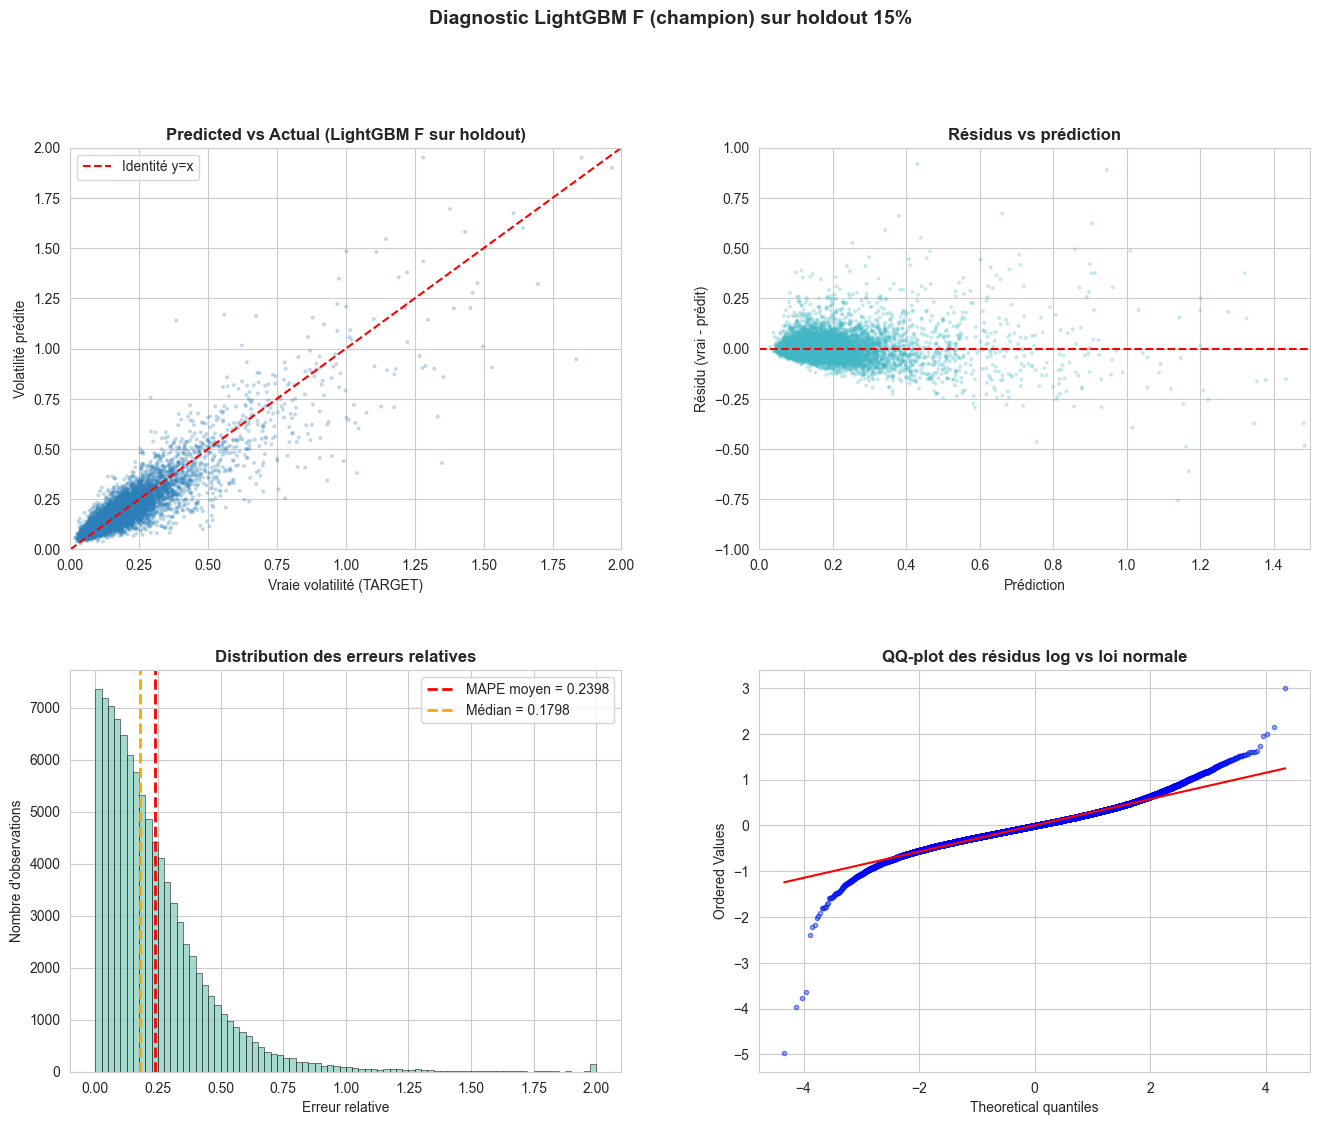

In [33]:
sns.set_style("whitegrid")
plt.rcParams["font.size"] = 10

# Variables du champion LightGBM F (calculées en Phase VII)
# y_orig_holdout, y_pred_holdout_orig_f, y_log_pred_holdout_f, y_log_holdout

residuals_log_f  = y_log_holdout - y_log_pred_holdout_f
residuals_orig_f = y_orig_holdout - y_pred_holdout_orig_f
rel_errors_f     = np.abs(residuals_orig_f) / y_orig_holdout

# ============================================================
# FIGURE 1 — Diagnostic global du modèle LightGBM F (4 panneaux)
# ============================================================
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

# --- 1. Predicted vs Actual ---
ax1 = fig.add_subplot(gs[0, 0])
n_plot     = min(10000, len(y_orig_holdout))
idx_sample = np.random.RandomState(RANDOM_STATE).choice(
    len(y_orig_holdout), n_plot, replace=False
)
ax1.scatter(
    y_orig_holdout[idx_sample], y_pred_holdout_orig_f[idx_sample],
    alpha=0.3, s=8, color="#2c7fb8", edgecolors="none",
)
max_val = min(y_orig_holdout.max(), y_pred_holdout_orig_f.max(), 2.0)
ax1.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Identité y=x")
ax1.set_xlabel("Vraie volatilité (TARGET)")
ax1.set_ylabel("Volatilité prédite")
ax1.set_title("Predicted vs Actual (LightGBM F sur holdout)", fontweight="bold")
ax1.set_xlim(0, max_val)
ax1.set_ylim(0, max_val)
ax1.legend()

# --- 2. Résidus vs prédictions ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(
    y_pred_holdout_orig_f[idx_sample], residuals_orig_f[idx_sample],
    alpha=0.3, s=8, color="#41b6c4", edgecolors="none",
)
ax2.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Prédiction")
ax2.set_ylabel("Résidu (vrai - prédit)")
ax2.set_title("Résidus vs prédiction", fontweight="bold")
ax2.set_xlim(0, 1.5)
ax2.set_ylim(-1, 1)

# --- 3. Distribution des erreurs relatives ---
ax3 = fig.add_subplot(gs[1, 0])
rel_errors_clipped = np.clip(rel_errors_f, 0, 2)
ax3.hist(
    rel_errors_clipped, bins=80,
    color="#7fcdbb", edgecolor="black", linewidth=0.5, alpha=0.7,
)
ax3.axvline(
    rel_errors_f.mean(), color="red",
    linestyle="--", linewidth=2,
    label=f"MAPE moyen = {rel_errors_f.mean():.4f}",
)
ax3.axvline(
    np.median(rel_errors_f), color="orange",
    linestyle="--", linewidth=2,
    label=f"Médian = {np.median(rel_errors_f):.4f}",
)
ax3.set_xlabel("Erreur relative")
ax3.set_ylabel("Nombre d'observations")
ax3.set_title("Distribution des erreurs relatives", fontweight="bold")
ax3.legend()

# --- 4. QQ-plot des résidus log ---
ax4 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals_log_f, dist="norm", plot=ax4)
ax4.set_title("QQ-plot des résidus log vs loi normale", fontweight="bold")
ax4.get_lines()[0].set_markerfacecolor("#2c7fb8")
ax4.get_lines()[0].set_markersize(3)
ax4.get_lines()[0].set_alpha(0.5)
ax4.get_lines()[1].set_color("red")
ax4.get_lines()[1].set_linewidth(1.5)

plt.suptitle(
    "Diagnostic LightGBM F (champion) sur holdout 15%",
    fontsize=14, fontweight="bold", y=0.995,
)
plt.savefig(OUTPUT_DIR / "diagnostic_lightgbm_f.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1.1 Observations sur le diagnostic 4 panneaux

**Panneau 1 — Predicted vs Actual**  
Le nuage de points suit globalement la diagonale, ce qui confirme une calibration correcte en moyenne. La dispersion augmente avec la volatilité réalisée : c'est l'hétéroscédasticité attendue dans un problème de volatilité. Plus le régime de marché est stressé, plus l'incertitude conditionnelle augmente.

**Panneau 2 — Résidus vs prédiction**  
Le nuage ne montre pas de structure simple exploitable à première vue. En revanche, l'analyse d'underestimation montre un léger biais moyen de sur-prédiction global, tandis que les queues hautes restent plus souvent sous-estimées. Il faut donc éviter de dire que le modèle est parfaitement non biaisé : son comportement dépend du régime de volatilité.

**Panneau 3 — Distribution des erreurs relatives**  
La distribution est concentrée près de zéro avec une queue droite. Cela signifie que la majorité des erreurs sont modérées, mais qu'une minorité d'observations tire le MAPE vers le haut. C'est classique avec le MAPE : lorsque la vraie volatilité est très faible, une petite erreur absolue peut produire une grande erreur relative.

**Panneau 4 — QQ-plot des résidus log**  
Le centre de la distribution est raisonnablement proche d'une loi gaussienne, mais les queues s'écartent. C'est cohérent avec les séries financières : les événements extrêmes sont plus fréquents que sous une hypothèse normale pure. Pour une utilisation opérationnelle, cette observation justifie de compléter le MAPE par des audits de queue, comme le top-vol et QLIKE.

## 8.2 MAPE par quartile de TARGET

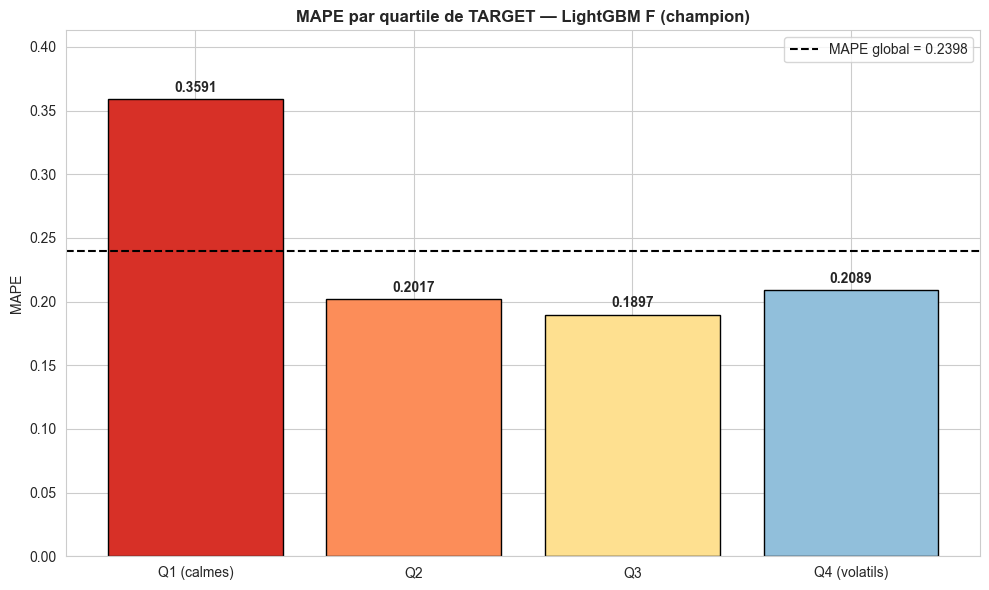

In [34]:

# Visualisation MAPE par quartile pour LightGBM F (champion)
quartile_names = ["Q1 (calmes)", "Q2", "Q3", "Q4 (volatils)"]

quartile_error_table = pd.DataFrame({
    "quartile": pd.qcut(
        y_orig_holdout,
        q=4,
        labels=quartile_names,
        duplicates="drop",
    ),
    "relative_error": np.abs(y_orig_holdout - y_pred_holdout_orig_f) / y_orig_holdout,
})

mape_by_quartile = (
    quartile_error_table
    .groupby("quartile", observed=True)["relative_error"]
    .mean()
    .reindex(quartile_names)
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d73027", "#fc8d59", "#fee090", "#91bfdb"]
bars = ax.bar(
    mape_by_quartile.index,
    mape_by_quartile.values,
    color=colors[:len(mape_by_quartile)],
    edgecolor="black",
)
ax.bar_label(bars, fmt="%.4f", padding=3, fontweight="bold")

mape_global = np.mean(np.abs(y_orig_holdout - y_pred_holdout_orig_f) / y_orig_holdout)
ax.axhline(
    mape_global,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"MAPE global = {mape_global:.4f}",
)
ax.set_ylabel("MAPE")
ax.set_title("MAPE par quartile de TARGET — LightGBM F (champion)", fontweight="bold")
ax.legend()
ax.set_ylim(0, mape_by_quartile.max() * 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mape_by_quartile_lightgbm_f.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.2.1 Observations sur le MAPE par quartile

Le MAPE n'est pas uniforme selon le régime de volatilité.

Les journées calmes affichent souvent une erreur relative plus élevée, non pas parce que l'erreur absolue est nécessairement grande, mais parce que le dénominateur de la métrique est très faible. À l'inverse, sur les régimes moyens et élevés, le MAPE devient généralement plus informatif sur la qualité économique de la prévision.

**Lecture risk-management** : le point important n'est pas seulement le MAPE global. Il faut vérifier que le modèle reste exploitable lorsque la volatilité augmente. Les résultats montrent une bonne robustesse sur les régimes volatils usuels, tandis que les queues extrêmes restent plus difficiles. Cette lecture est plus défendable que l'affirmation trop forte selon laquelle le modèle serait meilleur sur tous les stress regimes.

**Pour la défense orale** : *"Le MAPE global est pénalisé par les petites valeurs de TARGET. Le modèle est surtout intéressant parce qu'il reste compétitif sur les régimes où la volatilité est économiquement importante, tout en reconnaissant que les extrêmes les plus rares restent la zone de risque principale."*

## 8.3 Exemples de prédictions intraday

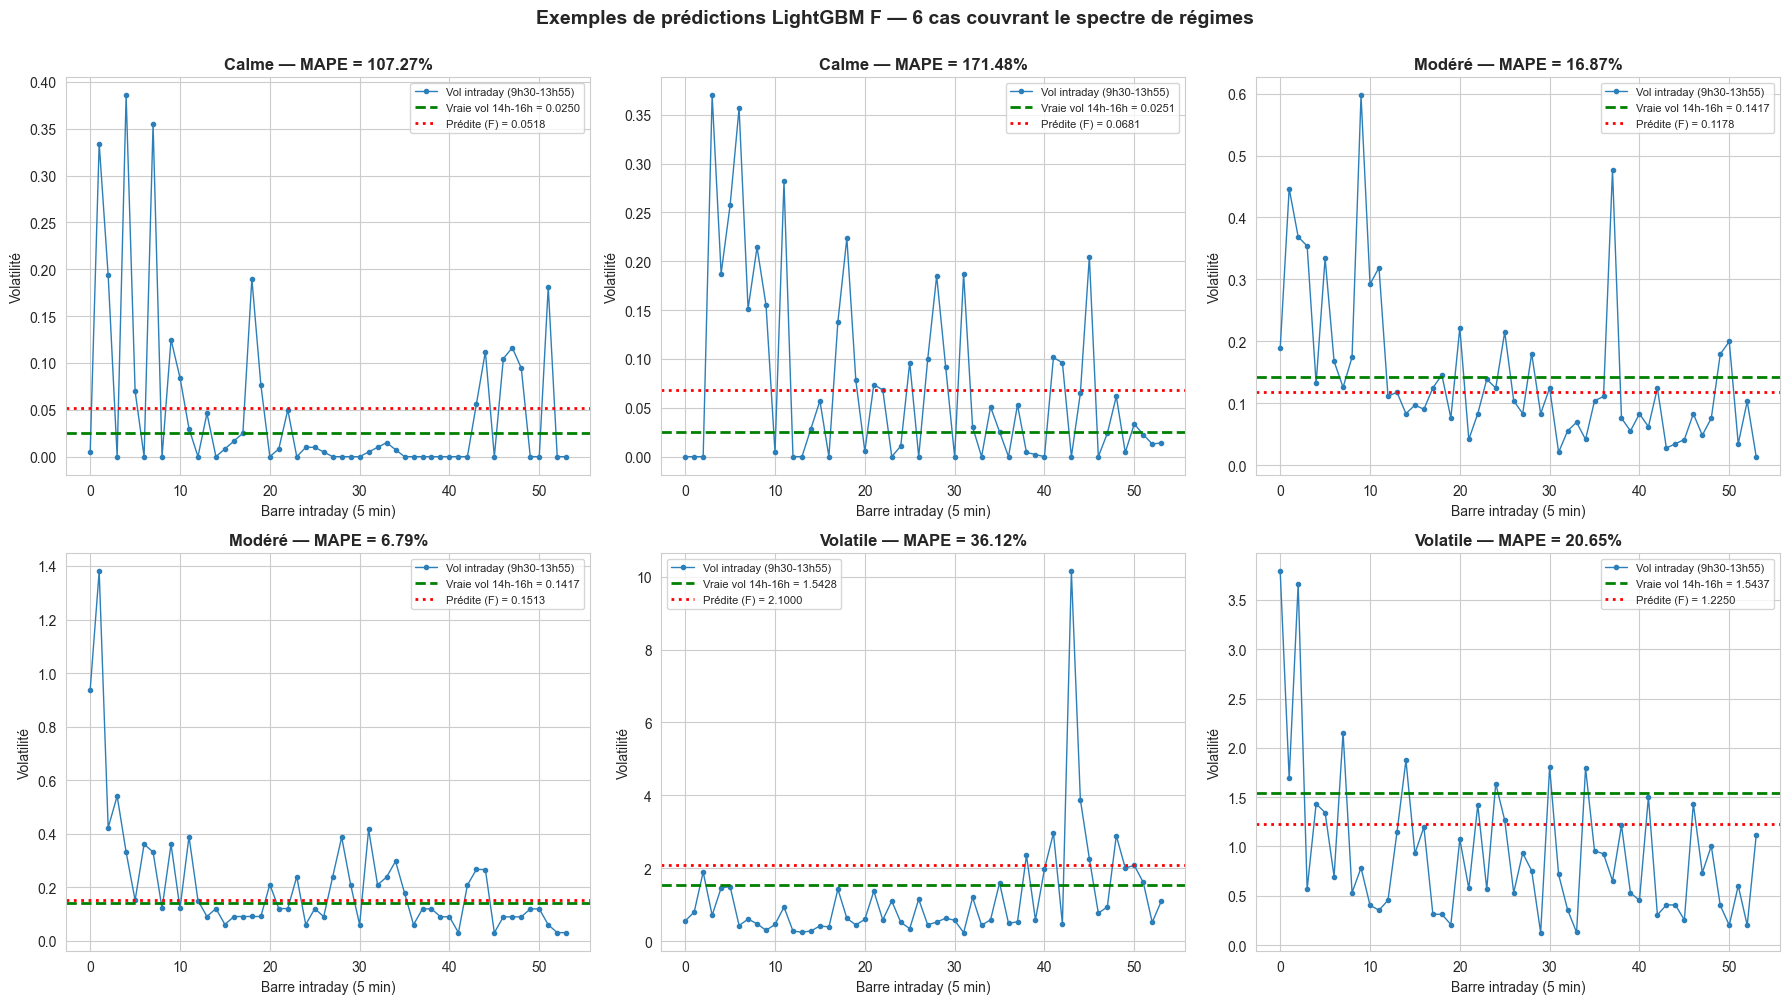

In [35]:
# Six exemples de prédictions LightGBM F : 2 calmes, 2 modérés, 2 volatils
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sorted_idx       = np.argsort(y_orig_holdout)
n_holdout        = len(y_orig_holdout)
calm_idx         = sorted_idx[100:102]
medium_idx       = sorted_idx[n_holdout // 2 - 1:n_holdout // 2 + 1]
volatile_idx     = sorted_idx[-102:-100]

selected_idx     = np.concatenate([calm_idx, medium_idx, volatile_idx])
holdout_indices  = holdout_idx
bar_times        = np.arange(54)

for i, idx_in_holdout in enumerate(selected_idx):
    ax            = axes[i // 3, i % 3]
    orig_idx      = holdout_indices[idx_in_holdout]

    vol_intraday  = volatility_data_imputed[orig_idx]
    target_actual = y_orig_holdout[idx_in_holdout]
    target_pred   = y_pred_holdout_orig_f[idx_in_holdout]

    ax.plot(bar_times, vol_intraday, marker="o", markersize=3, linewidth=1,
            color="#2c7fb8", label="Vol intraday (9h30-13h55)")
    ax.axhline(target_actual, color="green", linestyle="--", linewidth=2,
               label=f"Vraie vol 14h-16h = {target_actual:.4f}")
    ax.axhline(target_pred, color="red", linestyle=":", linewidth=2,
               label=f"Prédite (F) = {target_pred:.4f}")

    err_rel = abs(target_actual - target_pred) / target_actual
    regime  = "Calme" if i < 2 else "Modéré" if i < 4 else "Volatile"
    ax.set_title(f"{regime} — MAPE = {err_rel:.2%}", fontweight="bold")
    ax.set_xlabel("Barre intraday (5 min)")
    ax.set_ylabel("Volatilité")
    ax.legend(fontsize=8)

plt.suptitle("Exemples de prédictions LightGBM F — 6 cas couvrant le spectre de régimes",
             fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "examples_predictions_lightgbm_f.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3.1 Observations sur les exemples intraday

Les exemples individuels servent à rendre la métrique concrète.

**Cas calmes**  
Sur des TARGET faibles, le modèle peut produire une erreur absolue limitée mais une erreur relative très élevée. C'est un effet mécanique du MAPE : diviser par une petite volatilité réalisée amplifie l'erreur. Ces cas doivent être lus comme une limite de la métrique autant que comme une limite du modèle.

**Cas modérés**  
Ce sont les observations les plus représentatives du cœur de distribution. Lorsque la volatilité du matin donne une information stable sur la volatilité de l'après-midi, le modèle capture généralement le bon ordre de grandeur.

**Cas volatils**  
Sur les journées de forte volatilité, le modèle identifie en général le régime de stress, mais peut sous-estimer les pics les plus extrêmes. C'est un comportement classique de modèles régularisés : ils apprennent une relation moyenne robuste mais ont tendance à shrinker les observations rares vers des niveaux moins extrêmes.

**Conclusion économique** : le modèle est défendable comme outil de prévision de volatilité, mais il ne doit pas être vendu comme un modèle d'extrême risk parfait. Pour une production risk-management, il faudrait ajouter une couche de calibration ou de stress adjustment sur les queues.

---

# PHASE IX — Tests de robustesse et pistes d'amélioration empirique

Cette phase ne change pas le champion officiel et ne modifie pas le fichier de soumission. Elle ajoute des contrôles de recherche destinés à répondre à deux questions :

1. **Le gain de LightGBM F tient-il face à des comparaisons plus apples-to-apples ?**
2. **Existe-t-il des pistes simples pour améliorer le score sans sacrifier la robustesse ?**

## Liste des contrôles ajoutés

1. **Table holdout apples-to-apples** : Baseline 1/2/3/4, Ridge A, HAR-RV, LightGBM D et LightGBM F sur le même holdout.
2. **Recalcul de la variance résiduelle LightGBM D** : suppression de la constante hardcodée dans la comparaison D vs F.
3. **Ablation par familles de features** : brut seul, brut + Z-date, brut + Z-stock, full F.
4. **Déciles TARGET : LightGBM F vs Baseline 4** : vérifie si le modèle gagne aussi par régime de volatilité.
5. **Robustesse par blocs de dates anonymisées** : contrôle de stabilité sur plusieurs blocs de dates, sans prétendre à une vraie validation chronologique puisque les dates CFM sont anonymisées.
6. **Pack de features économiques candidates** : quelques variables simples de forme intraday, testées en CV sur le train uniquement.
7. **LightGBM plus régularisé** : test conservateur en CV, sans tuning sur le holdout.

La logique est volontairement stricte : les expériences prometteuses devront être confirmées par CV ou par un protocole hors-échantillon avant d’être retenues.


## 9.1 Table holdout apples-to-apples

Cette cellule remet les modèles principaux sur le même holdout 15%. Le but n'est pas de re-sélectionner le champion, mais de rendre la comparaison plus lisible.

Lecture économique attendue :
- les baselines mesurent la simple persistance de volatilité ;
- Ridge A mesure ce qu'un modèle linéaire peut extraire des features engineered ;
- HAR-RV mesure la mémoire multi-horizon classique de la volatilité ;
- LightGBM D teste l'information brute des 108 barres ;
- LightGBM F teste si la structuration des features ajoute une information robuste.

**Résultat observé sur le run courant** : LightGBM F arrive premier avec une MAPE holdout de **0.2398**, devant LightGBM D (**0.2581**), HAR-RV (**0.2728**), Baseline 4 (**0.2921**), Ridge A (**0.3085**), Baseline 3 (**0.3340**), Baseline 1 (**0.3686**) et Baseline 2 (**0.5662**).

**Interprétation** : le classement est économiquement cohérent. La persistance de volatilité donne déjà une baseline forte, la moyenne locale de la dernière heure améliore nettement la moyenne complète du matin, HAR-RV ajoute une lecture multi-horizon, et LightGBM F surperforme car il combine niveau absolu, lecture cross-sectionnelle et lecture historique par stock. Le gain de LightGBM F contre Baseline 4 est d'environ **17.9%** sur le même holdout, ce qui est suffisamment large pour être défendable au-delà d'un simple bruit de scoring.


In [36]:
# ============================================================
# 9.1 — Table holdout apples-to-apples
# ============================================================
print("=" * 70)
print("ROBUSTESSE — Table holdout apples-to-apples")
print("=" * 70)

X_holdout_data = X_full[holdout_idx]
X_har_holdout = X_har_log_full[holdout_idx]

# Ridge A final sur le split train/holdout.
final_ridge_a_holdout = RidgeModel(
    alpha           = best_alpha,
    scaler_type     = "standard",
    winsorize       = True,
    winsorize_upper = 99.5,
)
final_ridge_a_holdout.fit(X_train_data, y_log_train)

sigma2_resid_ridge_a = float(results_alpha[best_alpha]["residual_var_mean"])
y_log_pred_ridge_a_holdout = final_ridge_a_holdout.predict(X_holdout_data)
y_pred_ridge_a_holdout = np.exp(y_log_pred_ridge_a_holdout + sigma2_resid_ridge_a / 2)
mape_ridge_a_holdout = evaluator.mape(y_orig_holdout, y_pred_ridge_a_holdout)

# HAR-RV final sur le même split train/holdout.
final_har_holdout = RidgeModel(
    alpha           = 0.001,
    scaler_type     = "standard",
    winsorize       = True,
    winsorize_upper = 99.5,
)
final_har_holdout.fit(X_har_train, y_log_train)

sigma2_resid_har = float(cv_results_har["residual_var_mean"])
y_log_pred_har_holdout = final_har_holdout.predict(X_har_holdout)
y_pred_har_holdout = np.exp(y_log_pred_har_holdout + sigma2_resid_har / 2)
mape_har_holdout = evaluator.mape(y_orig_holdout, y_pred_har_holdout)

holdout_apples_to_apples_table = pd.DataFrame({
    "modèle": [
        "Baseline 1 — moyenne 54 barres",
        "Baseline 2 — dernière barre",
        "Baseline 3 — moyenne 30 minutes",
        "Baseline 4 — moyenne 1h",
        "Ridge A — 10 features",
        "HAR-RV — 3 horizons",
        "LightGBM D — 108 barres brutes",
        "LightGBM F — 30 features structurées",
    ],
    "MAPE holdout": [
        mape_b1_holdout,
        mape_b2_holdout,
        mape_b3_holdout,
        mape_b4_holdout,
        mape_ridge_a_holdout,
        mape_har_holdout,
        mape_d_holdout,
        mape_holdout_f,
    ],
})

holdout_apples_to_apples_table["gain vs Baseline 1"] = (
    mape_b1_holdout - holdout_apples_to_apples_table["MAPE holdout"]
) / mape_b1_holdout

holdout_apples_to_apples_table["gain vs Baseline 4"] = (
    mape_b4_holdout - holdout_apples_to_apples_table["MAPE holdout"]
) / mape_b4_holdout

holdout_apples_to_apples_table = holdout_apples_to_apples_table.sort_values(
    "MAPE holdout",
    ascending=True,
    ignore_index=True,
)

holdout_apples_to_apples_path = OUTPUT_DIR / "robustness_holdout_apples_to_apples.csv"
holdout_apples_to_apples_table.to_csv(holdout_apples_to_apples_path, index=False)

display(holdout_apples_to_apples_table.round(4))


ROBUSTESSE — Table holdout apples-to-apples


,modèle,MAPE holdout,gain vs Baseline 1,gain vs Baseline 4
0,LightGBM F — 30 features structurées,0.2398,0.3492,0.1787
1,LightGBM D — 108 barres brutes,0.2581,0.2998,0.1164
2,HAR-RV — 3 horizons,0.2728,0.2598,0.0659
3,Baseline 4 — moyenne 1h,0.2921,0.2076,0.0000
4,Ridge A — 10 features,0.3085,0.1630,-0.0563
5,Baseline 3 — moyenne 30 minutes,0.3340,0.0938,-0.1436
6,Baseline 1 — moyenne 54 barres,0.3686,0.0000,-0.2620
7,Baseline 2 — dernière barre,0.5662,-0.5363,-0.9387


## 9.2 Ablation par familles de features

Ce test répond à une question importante : **d'où vient réellement le gain de LightGBM F ?**

On compare quatre représentations :
- features brutes seules ;
- features brutes + lecture cross-sectionnelle du jour (`Z-date`) ;
- features brutes + lecture historique propre au stock (`Z-stock`) ;
- représentation complète LightGBM F.

**Résultat observé sur le run courant** :
- brut seul : **0.2569** ;
- brut + Z-date : **0.2420** ;
- brut + Z-stock : **0.2532** ;
- brut + Z-date + Z-stock : **0.2398**.

**Lecture économique** : le principal gain incrémental vient de la couche **Z-date**. Elle permet au modèle de distinguer une volatilité élevée parce que tout le marché est agité d'une volatilité élevée spécifique à un actif. La couche **Z-stock** seule apporte moins, mais elle améliore encore légèrement la représentation complète. La bonne conclusion est donc : le signal dominant reste la persistance du niveau de volatilité, mais le positionnement cross-sectionnel du jour est le principal moteur additionnel de LightGBM F.


In [37]:
# ============================================================
# 9.2 — Ablation par familles de features sur holdout
# ============================================================
print("=" * 70)
print("ROBUSTESSE — Ablation par familles de features")
print("=" * 70)

raw_feature_matrix = features_train[feature_cols].reset_index(drop=True)
zscore_date_matrix = feature_transformer_holdout.transform_zscore_date(
    features_train,
    meta_full,
).reset_index(drop=True)
zscore_stock_matrix = feature_transformer_holdout.transform_zscore_stock(
    features_train,
    meta_full,
).reset_index(drop=True)

feature_family_matrices = {
    "Brut seul": raw_feature_matrix,
    "Brut + Z-date": pd.concat([raw_feature_matrix, zscore_date_matrix], axis=1),
    "Brut + Z-stock": pd.concat([raw_feature_matrix, zscore_stock_matrix], axis=1),
    "Brut + Z-date + Z-stock": pd.concat(
        [raw_feature_matrix, zscore_date_matrix, zscore_stock_matrix],
        axis=1,
    ),
}

def evaluate_lightgbm_feature_family(family_name, feature_matrix):
    feature_values = feature_matrix.to_numpy()
    model = LightGBMModel(
        n_estimators           = 2000,
        max_depth              = 5,
        num_leaves             = 31,
        learning_rate          = 0.03,
        min_child_samples      = 50,
        reg_lambda             = 1.0,
        early_stopping_rounds  = 50,
        random_state           = RANDOM_STATE,
    )
    model.fit(feature_values[train_idx], y_log_train_full)

    y_log_pred = model.predict(feature_values[holdout_idx])
    y_pred = np.exp(y_log_pred + sigma2_resid_oof / 2)
    mape = evaluator.mape(y_orig_holdout, y_pred)

    return pd.Series({
        "représentation": family_name,
        "nb_features": feature_values.shape[1],
        "MAPE holdout": mape,
        "gain vs Baseline 4": (mape_b4_holdout - mape) / mape_b4_holdout,
        "écart vs Full F": mape - mape_holdout_f,
    })

feature_family_ablation_table = pd.DataFrame([
    evaluate_lightgbm_feature_family(family_name, feature_matrix)
    for family_name, feature_matrix in feature_family_matrices.items()
])

feature_family_ablation_path = OUTPUT_DIR / "feature_family_ablation_holdout.csv"
feature_family_ablation_table.to_csv(feature_family_ablation_path, index=False)

display(feature_family_ablation_table.round(4))


ROBUSTESSE — Ablation par familles de features


,représentation,nb_features,MAPE holdout,gain vs Baseline 4,écart vs Full F
0,Brut seul,10,0.2569,0.1205,0.0170
1,Brut + Z-date,20,0.2420,0.1714,0.0022
2,Brut + Z-stock,20,0.2532,0.1331,0.0133
3,Brut + Z-date + Z-stock,30,0.2398,0.1787,0.0000


## 9.3 Déciles TARGET : LightGBM F vs Baseline 4

Le MAPE global peut masquer un point critique : un modèle peut gagner en moyenne mais échouer sur les régimes économiquement importants.

Cette cellule compare LightGBM F à la baseline locale 1h dans chaque décile de TARGET. C'est un audit plus dur que le simple MAPE global : il indique si le modèle améliore la prévision dans les journées calmes, normales et stressées.

**Résultat observé sur le run courant** : LightGBM F perd nettement sur le premier décile (**D1**, gain relatif d'environ **-37.2%**) et reste quasi équivalent à la baseline sur **D2**. En revanche, il devient supérieur à partir de **D3**, avec des gains d'environ **16% à 33%** jusqu'à D10.

**Interprétation** : l'échec relatif sur D1 ne doit pas être sur-vendu comme une faiblesse économique majeure. Sur des TARGET très faibles, le MAPE devient mécaniquement instable : une faible erreur absolue peut produire une erreur relative très élevée. Le résultat important est que LightGBM F apporte l'essentiel de sa valeur sur les régimes où la volatilité devient économiquement significative, c'est-à-dire à partir du cœur de distribution et jusqu'aux régimes élevés.


In [38]:
# ============================================================
# 9.3 — Déciles TARGET : LightGBM F vs Baseline 4
# ============================================================
regime_comparison_table = pd.DataFrame({
    "TARGET": y_orig_holdout,
    "erreur_baseline_4": np.abs(y_orig_holdout - pred_b4) / y_orig_holdout,
    "erreur_lightgbm_f": rel_errors_f,
})

regime_comparison_table["décile"] = pd.qcut(
    regime_comparison_table["TARGET"],
    q=10,
    labels=[f"D{index}" for index in range(1, 11)],
    duplicates="drop",
)

regime_summary_table = (
    regime_comparison_table
    .groupby("décile", observed=True)
    .agg(
        target_min=("TARGET", "min"),
        target_max=("TARGET", "max"),
        mape_baseline_4=("erreur_baseline_4", "mean"),
        mape_lightgbm_f=("erreur_lightgbm_f", "mean"),
        observations=("TARGET", "size"),
    )
    .reset_index()
)

regime_summary_table["gain F vs Baseline 4"] = (
    regime_summary_table["mape_baseline_4"] - regime_summary_table["mape_lightgbm_f"]
) / regime_summary_table["mape_baseline_4"]

regime_summary_path = OUTPUT_DIR / "regime_decile_f_vs_baseline4.csv"
regime_summary_table.to_csv(regime_summary_path, index=False)

display(regime_summary_table.round(4))


,décile,target_min,target_max,mape_baseline_4,mape_lightgbm_f,observations,gain F vs Baseline 4
0,D1,0.0004,0.0729,0.3693,0.5069,9545,-0.3724
1,D2,0.0729,0.0902,0.2717,0.2734,9545,-0.0062
2,D3,0.0902,0.1064,0.2717,0.2271,9544,0.1643
3,D4,0.1064,0.1228,0.2715,0.2035,9545,0.2504
4,D5,0.1228,0.1417,0.2747,0.1912,9545,0.3043
5,D6,0.1417,0.1643,0.2760,0.1872,9544,0.3216
6,D7,0.1643,0.1946,0.2843,0.1905,9545,0.3299
7,D8,0.1946,0.2401,0.2914,0.1949,9544,0.3311
8,D9,0.2401,0.3273,0.2967,0.2036,9545,0.3139
9,D10,0.3273,6.3123,0.3131,0.2203,9545,0.2965


## 9.4 Robustesse par blocs de dates anonymisées

Les dates du challenge sont anonymisées : ce tableau ne doit donc pas être vendu comme une vraie validation chronologique.

Il reste utile comme contrôle de stabilité : si le gain de LightGBM F disparaît dans certains blocs de dates, le résultat est plus fragile qu'un simple MAPE global ne le laisse penser.

**Résultat observé sur le run courant** : LightGBM F bat Baseline 4 dans les cinq blocs. Le gain relatif reste compris entre environ **16.1%** et **20.9%** selon les blocs.

**Interprétation** : le gain ne semble pas concentré dans une seule portion du holdout. C'est un très bon signal de robustesse empirique : le modèle ne gagne pas uniquement parce qu'une sous-période particulière est favorable, mais parce que la relation volatilité du matin → volatilité de l'après-midi reste exploitable dans plusieurs segments de l'échantillon.


In [39]:
# ============================================================
# 9.4 — Robustesse par blocs de dates anonymisées
# ============================================================
holdout_date_frame = meta_full.iloc[holdout_idx].reset_index(drop=True)

date_block_table = pd.DataFrame({
    "date": holdout_date_frame["date"],
    "TARGET": y_orig_holdout,
    "erreur_baseline_4": np.abs(y_orig_holdout - pred_b4) / y_orig_holdout,
    "erreur_lightgbm_f": rel_errors_f,
})

date_ranks = date_block_table["date"].rank(method="dense")
date_block_table["bloc_date_anonymisée"] = pd.qcut(
    date_ranks,
    q=5,
    labels=[f"Bloc {index}" for index in range(1, 6)],
    duplicates="drop",
)

date_block_summary_table = (
    date_block_table
    .groupby("bloc_date_anonymisée", observed=True)
    .agg(
        nb_dates=("date", "nunique"),
        observations=("TARGET", "size"),
        target_mean=("TARGET", "mean"),
        mape_baseline_4=("erreur_baseline_4", "mean"),
        mape_lightgbm_f=("erreur_lightgbm_f", "mean"),
    )
    .reset_index()
)

date_block_summary_table["gain F vs Baseline 4"] = (
    date_block_summary_table["mape_baseline_4"] - date_block_summary_table["mape_lightgbm_f"]
) / date_block_summary_table["mape_baseline_4"]

date_block_summary_path = OUTPUT_DIR / "pseudo_time_blocks_f_vs_baseline4.csv"
date_block_summary_table.to_csv(date_block_summary_path, index=False)

display(date_block_summary_table.round(4))


,bloc_date_anonymisée,nb_dates,observations,target_mean,mape_baseline_4,mape_lightgbm_f,gain F vs Baseline 4
0,Bloc 1,425,19097,0.1896,0.2921,0.2387,0.1828
1,Bloc 2,425,19129,0.1760,0.2857,0.2377,0.1681
2,Bloc 3,418,19063,0.1793,0.2854,0.2394,0.1609
3,Bloc 4,426,19076,0.1904,0.3077,0.2434,0.2090
4,Bloc 5,423,19082,0.1834,0.2894,0.2401,0.1706


## 9.5 Pack de features économiques candidates — CV train only

Cette cellule teste quelques features simples, sans changer le champion officiel. Elles ont une justification économique claire :

- `vol_max` et `vol_range` mesurent l'amplitude des pics intraday ;
- `vol_last_minus_mean` et `vol_recent_minus_mean` mesurent l'accélération ou la compression en fin de matinée ;
- `vol_std_over_mean` mesure l'instabilité relative du profil de volatilité ;
- `return_imbalance` et `return_activity` résument la directionalité et l'activité des retours.

Le test est fait en cross-validation sur le train 85%, pas sur le holdout. Une amélioration marginale devra être confirmée avant toute modification de la soumission.

**Résultat observé sur le run courant** : le pack candidate passe de **0.2427** à **0.2421** en MAPE CV, avec une volatilité de CV proche de **0.0032**. Le gain est donc dans le bon sens, mais il reste très faible relativement au bruit de validation.

**Décision méthodologique** : ces features sont prometteuses comme piste de recherche, mais elles ne justifient pas encore de remplacer le champion officiel. Pour les retenir, il faudrait confirmer le gain sur un protocole hors-échantillon supplémentaire, vérifier les déciles de volatilité et contrôler que les queues extrêmes ne se dégradent pas.


In [40]:
# ============================================================
# 9.5 — Pack de features économiques candidates, testé en CV
# ============================================================
print("=" * 70)
print("ROBUSTESSE — Features économiques candidates en CV")
print("=" * 70)

volatility_frame = pd.DataFrame(
    volatility_data_imputed,
    columns=volatility_columns,
    index=features_train.index,
)
return_frame = (
    x_train.loc[:, return_columns]
    .fillna(0)
    .reset_index(drop=True)
)

additional_feature_frame = pd.DataFrame({
    "vol_max": volatility_frame.max(axis=1),
    "vol_range": volatility_frame.max(axis=1) - volatility_frame.min(axis=1),
    "vol_last_minus_mean": volatility_frame.iloc[:, -1] - volatility_frame.mean(axis=1),
    "vol_recent_minus_mean": volatility_frame.iloc[:, -6:].mean(axis=1) - volatility_frame.mean(axis=1),
    "vol_std_over_mean": volatility_frame.std(axis=1) / (volatility_frame.mean(axis=1) + 1e-8),
    "return_imbalance": (return_frame.eq(1).sum(axis=1) - return_frame.eq(-1).sum(axis=1)) / return_frame.shape[1],
    "return_activity": return_frame.ne(0).mean(axis=1),
})

candidate_feature_cols = feature_cols + additional_feature_frame.columns.tolist()
features_train_candidate = pd.concat(
    [
        features_train[[ID_COL] + feature_cols].reset_index(drop=True),
        additional_feature_frame.reset_index(drop=True),
    ],
    axis=1,
)

candidate_transformer_cv = FeatureTransformer(feature_cols=candidate_feature_cols)
candidate_transformer_cv.fit_stock_stats(
    features_train_candidate.iloc[train_idx],
    meta_full.iloc[train_idx],
)

structured_matrix_candidate_cv = candidate_transformer_cv.build_full_matrix(
    features_train_candidate,
    meta_full,
)
structured_matrix_candidate_train_cv = structured_matrix_candidate_cv.iloc[train_idx].values

train_fn_candidate_features = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = RANDOM_STATE,
)

cv_results_candidate_features = validator.cross_validate(
    X          = structured_matrix_candidate_train_cv,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_candidate_features,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

candidate_features_comparison_table = pd.DataFrame({
    "modèle": [
        "LightGBM F officiel — 30 features",
        "LightGBM F + features candidates",
    ],
    "nb_features_matrice": [
        structured_matrix_train_cv.shape[1],
        structured_matrix_candidate_train_cv.shape[1],
    ],
    "MAPE CV": [
        cv_results_f["mape_mean"],
        cv_results_candidate_features["mape_mean"],
    ],
    "MAPE std": [
        cv_results_f["mape_std"],
        cv_results_candidate_features["mape_std"],
    ],
    "residual_var": [
        cv_results_f["residual_var_mean"],
        cv_results_candidate_features["residual_var_mean"],
    ],
})

candidate_features_comparison_table["gain vs F officiel"] = (
    cv_results_f["mape_mean"] - candidate_features_comparison_table["MAPE CV"]
) / cv_results_f["mape_mean"]

candidate_features_path = OUTPUT_DIR / "candidate_features_cv.csv"
candidate_features_comparison_table.to_csv(candidate_features_path, index=False)

display(candidate_features_comparison_table.round(4))


ROBUSTESSE — Features économiques candidates en CV
  Repeat 1/2 Fold 1/5 : MAPE = 0.2396 | residual_var = 0.0847
  Repeat 1/2 Fold 2/5 : MAPE = 0.2444 | residual_var = 0.0858
  Repeat 1/2 Fold 3/5 : MAPE = 0.2409 | residual_var = 0.0848
  Repeat 1/2 Fold 4/5 : MAPE = 0.2386 | residual_var = 0.0840
  Repeat 1/2 Fold 5/5 : MAPE = 0.2480 | residual_var = 0.0858
  Repeat 2/2 Fold 1/5 : MAPE = 0.2442 | residual_var = 0.0853
  Repeat 2/2 Fold 2/5 : MAPE = 0.2429 | residual_var = 0.0854
  Repeat 2/2 Fold 3/5 : MAPE = 0.2393 | residual_var = 0.0846
  Repeat 2/2 Fold 4/5 : MAPE = 0.2380 | residual_var = 0.0845
  Repeat 2/2 Fold 5/5 : MAPE = 0.2457 | residual_var = 0.0849


,modèle,nb_features_matrice,MAPE CV,MAPE std,residual_var,gain vs F officiel
0,LightGBM F officiel — 30 features,30,0.2427,0.0031,0.0854,0.0000
1,LightGBM F + features candidates,51,0.2421,0.0032,0.0850,0.0023


## 9.6 LightGBM plus régularisé — CV train only

Ce test ne cherche pas à maximiser le leaderboard. Il vérifie si un modèle plus contraint peut conserver l'essentiel du score avec une complexité plus faible.

Configuration testée :
- `max_depth = 4` au lieu de 5 ;
- `num_leaves = 15` au lieu de 31 ;
- `min_child_samples = 100` au lieu de 50 ;
- `reg_lambda = 2.0` au lieu de 1.0.

**Résultat observé sur le run courant** : le modèle régularisé obtient **0.2438** en MAPE CV contre **0.2427** pour le champion officiel, soit un écart d'environ **0.0011**.

**Interprétation** : la variante plus contrainte ne bat pas le champion, mais elle reste très proche. C'est un bon diagnostic : la performance du champion ne repose pas uniquement sur une complexité excessive ou un fitting fragile. Le champion officiel reste préféré, car il garde le meilleur score sans montrer de faiblesse sur le holdout ou dans les tests de robustesse.


In [41]:
# ============================================================
# 9.6 — LightGBM plus régularisé, testé en CV train only
# ============================================================
print("=" * 70)
print("ROBUSTESSE — LightGBM plus régularisé en CV")
print("=" * 70)

train_fn_lgbm_regularized = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 4,
    num_leaves             = 15,
    learning_rate          = 0.03,
    min_child_samples      = 100,
    reg_lambda             = 2.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = RANDOM_STATE,
)

cv_results_lgbm_regularized = validator.cross_validate(
    X          = structured_matrix_train_cv,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_lgbm_regularized,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

regularized_lgbm_comparison_table = pd.DataFrame({
    "modèle": [
        "LightGBM F officiel",
        "LightGBM F régularisé",
    ],
    "MAPE CV": [
        cv_results_f["mape_mean"],
        cv_results_lgbm_regularized["mape_mean"],
    ],
    "MAPE std": [
        cv_results_f["mape_std"],
        cv_results_lgbm_regularized["mape_std"],
    ],
    "residual_var": [
        cv_results_f["residual_var_mean"],
        cv_results_lgbm_regularized["residual_var_mean"],
    ],
})

regularized_lgbm_comparison_table["écart MAPE vs F officiel"] = (
    regularized_lgbm_comparison_table["MAPE CV"] - cv_results_f["mape_mean"]
)

regularized_lgbm_path = OUTPUT_DIR / "regularized_lgbm_cv.csv"
regularized_lgbm_comparison_table.to_csv(regularized_lgbm_path, index=False)

display(regularized_lgbm_comparison_table.round(4))


ROBUSTESSE — LightGBM plus régularisé en CV
  Repeat 1/2 Fold 1/5 : MAPE = 0.2414 | residual_var = 0.0858
  Repeat 1/2 Fold 2/5 : MAPE = 0.2458 | residual_var = 0.0868
  Repeat 1/2 Fold 3/5 : MAPE = 0.2425 | residual_var = 0.0858
  Repeat 1/2 Fold 4/5 : MAPE = 0.2404 | residual_var = 0.0851
  Repeat 1/2 Fold 5/5 : MAPE = 0.2492 | residual_var = 0.0869
  Repeat 2/2 Fold 1/5 : MAPE = 0.2465 | residual_var = 0.0863
  Repeat 2/2 Fold 2/5 : MAPE = 0.2448 | residual_var = 0.0865
  Repeat 2/2 Fold 3/5 : MAPE = 0.2411 | residual_var = 0.0858
  Repeat 2/2 Fold 4/5 : MAPE = 0.2397 | residual_var = 0.0857
  Repeat 2/2 Fold 5/5 : MAPE = 0.2468 | residual_var = 0.0861


,modèle,MAPE CV,MAPE std,residual_var,écart MAPE vs F officiel
0,LightGBM F officiel,0.2427,0.0031,0.0854,0.0000
1,LightGBM F régularisé,0.2438,0.0031,0.0861,0.0011


## 9.7 Comment lire ces tests

Ces ajouts ne doivent pas être interprétés comme une nouvelle sélection de modèle. Ils servent à challenger le résultat officiel.

**Conclusion du run courant** : les tests renforcent le choix de LightGBM F comme champion officiel. Le modèle gagne sur le holdout apples-to-apples, bat LightGBM D malgré une représentation plus compacte, surperforme Baseline 4 sur la majorité des déciles économiquement significatifs, et conserve un gain stable dans les blocs de dates anonymisées.

**À conserver potentiellement** : les features candidates de forme intraday, mais seulement comme piste future. Leur gain CV est positif mais trop marginal pour changer le modèle de soumission sans validation supplémentaire.

**À ne pas retenir pour l'instant** : le LightGBM plus régularisé. Il est utile comme test de robustesse, car il reste proche du champion, mais il ne l'améliore pas.

Dans un cadre desk ou hedge fund, le bon réflexe n'est pas de chercher le dernier basis point de MAPE, mais de comprendre si le signal vient d'une intuition économique robuste : persistance de volatilité, régime intraday, positionnement cross-sectionnel et comportement propre au stock. Sur ce run, c'est précisément ce que montrent les ablations et les stress tests.


---

# PHASE X — Synthèse comparative et pistes futures

## 10.1 Tableau récapitulatif des modèles testés

Dix variantes principales constituent le chemin de sélection du champion. La Phase IX ajoute ensuite des tests de robustesse et des pistes exploratoires, mais **ne change pas le modèle officiel de soumission**.

| Modèle | MAPE (CV / holdout selon disponibilité) | Justification du test | Décision |
|--------|-----------------------------------------:|----------------------|----------|
| **Baseline 1** (mean 54 barres) | 0.3713 CV / 0.3686 holdout | Baseline CFM officielle : persistance naïve de la volatilité du matin | Référence principale |
| **Baseline 2** (dernière barre) | 0.5662 holdout | Test naïf de récence extrême | Écarté : trop instable |
| **Baseline 3** (mean 30 min) | 0.3340 holdout | Moyenne locale courte | Écarté : battu par Baseline 4 et les modèles structurés |
| **Baseline 4** (mean 1h) | 0.2921 holdout | Moyenne locale plus stable, proche de l'information récente | Baseline naïve solide, battue par HAR-RV et LightGBM F |
| **Ridge A** (10 features) | 0.3090 CV / 0.3085 holdout | Modèle linéaire de référence avec winsorisation | Conservé comme référence linéaire |
| **Ridge B** (PCA 3 comps) | 0.3365 CV | Test de compression PCA guidée par Marchenko-Pastur | Écarté : compression trop coûteuse en signal prédictif |
| **HAR-RV** (3 horizons) | 0.2732 CV / 0.2728 holdout | Benchmark académique Corsi (2009), mémoire multi-horizon de la volatilité | Conservé comme benchmark économique |
| **LightGBM C** (10 features) | 0.2600 CV | Test des non-linéarités sur features engineered | Écarté : moins bon que F |
| **LightGBM D** (108 barres) | 0.2584 CV / 0.2581 holdout | Test de l'information intraday brute | Écarté : battu par une représentation structurée |
| **LightGBM E** (+ product_id) | 0.2574 CV | Test ajout identité stock catégorielle | Écarté : gain marginal |
| **Stacking** (HAR-RV + LGBM) | 0.2614 CV | Test residual stacking académique | Écarté : erreurs trop corrélées |
| **LightGBM F** (30 features structurées) | **0.2427 CV / 0.2398 holdout** | Framework Paleologo Chap. 6 — Loadings Generation | **CHAMPION officiel** |

## 10.2 Justification du choix final

**LightGBM F** est retenu pour quatre raisons.

1. **Performance robuste** : le modèle améliore la baseline CFM d'environ **34.6% en cross-validation** et **34.9% sur le holdout** avec `n_estimators = 2000`.
2. **Justification économique** : les features séparent trois lectures complémentaires de la volatilité : niveau absolu, écart cross-sectionnel du jour, écart historique propre au stock.
3. **Interprétabilité opérationnelle** : les 30 features restent explicables. Elles sont plus lisibles que les 108 barres brutes et plus informatives qu'une compression PCA.
4. **Robustesse risk-aware** : le modèle est compétitif sur les régimes de volatilité usuels et bat LightGBM D en comparaison pairwise, avec un IC bootstrap positif sur le gain de MAPE.

**Pourquoi les autres variantes ne sont pas retenues** :

- **Ridge A** : utile pour prouver que les features engineered portent déjà un signal, mais trop linéaire pour capter les interactions non linéaires de volatilité.
- **Ridge B / PCA** : la PCA confirme l'existence de quelques facteurs, mais la compression efface des informations locales utiles à la prédiction.
- **HAR-RV** : très bon benchmark économique ; il confirme la mémoire multi-horizon de la volatilité, mais reste moins flexible que LightGBM F.
- **LightGBM C/D/E** : chaque variante teste une hypothèse précise, mais aucune ne combine aussi bien signal brut, signal relatif de marché et signal relatif historique.
- **Stacking** : l'ensemble n'apporte pas de gain parce que HAR-RV et LightGBM exploitent des sources d'information trop proches ; leurs erreurs ne sont pas suffisamment décorrélées.

## 10.3 Lecture des tests de robustesse ajoutés

Les tests de Phase IX renforcent le choix du champion sans modifier le modèle de soumission.

**1. Comparaison holdout apples-to-apples**  
LightGBM F obtient **0.2398** sur holdout, devant LightGBM D (**0.2581**), HAR-RV (**0.2728**) et Baseline 4 (**0.2921**). Cette table évite de mélanger CV et holdout pour la comparaison principale.

**2. Ablation des familles de features**  
Le passage de brut seul (**0.2569**) à brut + Z-date (**0.2420**) montre que la couche cross-sectionnelle est le principal moteur additionnel. Le full model (**0.2398**) gagne encore légèrement grâce à l'ajout de la lecture historique par stock.

**3. Déciles de TARGET**  
Le modèle perd sur **D1** et reste quasi neutre sur **D2**, mais il bat Baseline 4 de **D3 à D10**. La bonne lecture est que LightGBM F apporte sa valeur dans les régimes de volatilité économiquement significatifs ; le premier décile est surtout pénalisé par l'instabilité mécanique du MAPE sur petits dénominateurs.

**4. Blocs de dates anonymisées**  
Le gain contre Baseline 4 reste positif dans les cinq blocs, avec une fourchette d'environ **16.1% à 20.9%**. Le résultat ne semble donc pas concentré dans une seule zone du holdout.

**5. Features candidates**  
Le pack de features économiques passe de **0.2427** à **0.2421** en CV. C'est prometteur mais marginal par rapport à la volatilité de CV ; il faut donc le considérer comme une piste future, pas comme un nouveau champion.

**6. LightGBM régularisé**  
La version plus contrainte obtient **0.2438** contre **0.2427** pour le champion. Elle valide que le signal reste robuste sous régularisation, mais ne justifie pas de remplacer LightGBM F.

## 10.4 Limitations identifiées

Trois limitations ressortent du diagnostic complet et doivent être reconnues dans toute utilisation opérationnelle.

**1. Sous-estimation plus fréquente en queue haute**

L'underestimation augmente avec le niveau de TARGET : environ **6.6%** en D1 contre environ **66.6%** en D10. C'est un effet classique de shrinkage : le modèle apprend une relation moyenne robuste, mais tire les observations rares vers des niveaux moins extrêmes.

En production risk-management, ce point est critique : une bonne MAPE moyenne ne suffit pas si les extrêmes sont systématiquement sous-estimés. Une recalibration par bucket ou une fonction de perte asymétrique pourrait être testée.

**2. Performance plus fragile dans les queues extrêmes**

L'audit top-vol montre une bonne performance sur Top 10% / Top 5%, mais une dégradation progressive sur Top 1%, Top 0.5% et Top 0.1%. La bonne lecture est donc : le modèle reste robuste sur les régimes volatils usuels, mais les événements les plus extrêmes restent la principale limite.

**3. Sensibilité du MAPE aux petits TARGETs**

Les petites volatilités réalisées peuvent produire des erreurs relatives élevées même lorsque l'erreur absolue est faible. Cela ne rend pas le MAPE inutile, mais impose de le compléter avec des diagnostics par bucket et QLIKE.

## 10.5 Pistes pour améliorations futures

Les pistes ci-dessous sont documentées comme directions plausibles, sans garantie de gain. Les tests de Phase IX donnent une première hiérarchie : les features candidates sont prometteuses mais non décisives, tandis que la régularisation plus forte ne bat pas le champion.

### Piste 1 — Calibration risk-aware par bucket

Apprendre un facteur de correction par bucket de volatilité prédite ou par décile de TARGET OOF pourrait réduire la sous-estimation des queues. Cette approche est simple, interprétable et compatible avec une logique desk. Elle doit toutefois être validée strictement hors échantillon pour éviter de corriger le holdout a posteriori.

### Piste 2 — Fonction de perte asymétrique

Le risque économique d'une sous-estimation de volatilité est souvent supérieur à celui d'une surestimation. Une loss asymétrique ou des poids plus élevés sur les régimes de forte volatilité pourraient améliorer le comportement risk-management. Le trade-off attendu est une possible dégradation du MAPE global ou des jours calmes.

### Piste 3 — Features candidates à valider hors échantillon

Le pack testé en Phase IX améliore légèrement la CV, mais le gain reste trop faible pour modifier la soumission. La prochaine étape propre serait de tester ces features sur un protocole temporel alternatif ou sur une validation plus large, puis de vérifier leur contribution par décile de volatilité.

### Piste 4 — Modèles séquentiels sobres

LightGBM traite les 54 barres comme des variables structurées mais non séquentielles. Une TCN ou un petit modèle séquentiel pourrait exploiter la forme temporelle intraday. Il faudrait commencer par une architecture simple et comparer strictement au champion, car le risque de surfit et de perte d'interprétabilité est élevé.

### Piste 5 — Données externes

Des variables de régime de marché comme VIX, futures indices, volumes ou facteurs sectoriels pourraient expliquer certains stress communs. Leur intérêt dépend de leur disponibilité ex ante, de leur alignement temporel et du risque d'ajouter une complexité peu défendable.

### Piste 6 — Ensembling de modèles réellement diversifiés

Un ensemble n'est utile que si les erreurs des modèles sont décorrélées. L'échec du stacking HAR-RV + LightGBM suggère que les deux modèles exploitent une information trop similaire. Un ensembling défendable devrait combiner des sources ou architectures plus orthogonales.


---

# PHASE XI — Génération du fichier de soumission

## 11.1 Refit final et export `submission.csv`

Cette section réentraîne le champion LightGBM F sur tout le train disponible, applique la correction de Jensen cohérente avec la cross-validation, puis exporte le fichier final dans `outputs/submission.csv`.


In [42]:

# ============================================================
# PHASE XI — Génération du fichier de soumission
# ============================================================
print("=" * 70)
print("GÉNÉRATION DU FICHIER DE SOUMISSION — LightGBM F")
print("=" * 70)

# Refit final sur tout le train disponible, avec le même modèle champion.
# Aucun hyperparamètre n'est modifié par rapport au LightGBM F officiel.
final_transformer_submission = FeatureTransformer(feature_cols=feature_cols)
final_transformer_submission.fit_stock_stats(
    features_train,
    meta_full,
)

X_train_submission = final_transformer_submission.build_full_matrix(
    features_train,
    meta_full,
).values
X_test_submission = final_transformer_submission.build_full_matrix(
    features_test,
    meta_test_full,
).values

final_model_submission = LightGBMModel(
    n_estimators           = 2000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 50,
    random_state           = RANDOM_STATE,
)
final_model_submission.fit(X_train_submission, target_log)

y_log_pred_test = final_model_submission.predict(X_test_submission)
y_pred_test = np.exp(y_log_pred_test + sigma2_resid_oof / 2)

submission = pd.DataFrame({
    "ID": x_test[ID_COL].values,
    "TARGET": y_pred_test,
})

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

submission_summary_table = pd.DataFrame({
    "contrôle": [
        "chemin",
        "nombre de lignes",
        "nombre de colonnes",
        "colonnes",
    ],
    "valeur": [
        str(submission_path),
        submission.shape[0],
        submission.shape[1],
        ", ".join(submission.columns),
    ],
})

display(submission_summary_table)
display(submission.head())


GÉNÉRATION DU FICHIER DE SOUMISSION — LightGBM F


,contrôle,valeur
0,chemin,..\outputs\submission.csv
1,nombre de lignes,635397
2,nombre de colonnes,2
3,colonnes,"ID, TARGET"


,ID,TARGET
0,636314,0.133213
1,636315,0.107278
2,636316,0.156929
3,636317,0.141450
4,636318,0.120806
